<a href="https://colab.research.google.com/github/QwertyJacob/deep_active_inference_tutorial/blob/main/esp_undergrad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción a la Inferencia Activa
_______
Por Jesus Cevallos


## 1. Introducción: ¿Qué es la Probabilidad?
_______

> *"La probabilidad no describe el mundo. Describe lo que sabemos sobre el mundo."*
> — E.T. Jaynes





### ¿Por qué empezar por la probabilidad?

Antes de hablar de inteligencia artificial, de redes neuronales, o de agentes que aprenden a navegar el mundo, necesitamos hacernos una pregunta aparentemente simple:

**¿Cómo representa un sistema —natural o artificial— su incertidumbre sobre el mundo?**

La respuesta, sorprendentemente, es siempre la misma: **mediante la probabilidad**.

Pero la probabilidad no es una sola cosa. A lo largo de la historia, los matemáticos, estadísticos y filósofos han propuesto distintas formas de interpretarla. Entender estas diferencias no es un ejercicio puramente académico: es el fundamento conceptual de todo lo que vendrá después en este tutorial.

Veamos las tres grandes interpretaciones.

### 1. La Definición Clásica (o Laplaciana)

La definición más antigua y más intuitiva de probabilidad se debe al matemático francés **Pierre-Simon Laplace** (siglo XVIII). Su idea es elegante en su simplicidad:

> Si un experimento tiene $N$ resultados posibles **igualmente probables**, y un evento $A$ ocurre en $m$ de esos resultados, entonces:
>
> $$P(A) = \frac{m}{N}$$

#### Ejemplo

Al lanzar un dado justo de seis caras, ¿cuál es la probabilidad de obtener un número par?

- Resultados posibles: $\{1, 2, 3, 4, 5, 6\}$ → $N = 6$
- Resultados favorables (pares): $\{2, 4, 6\}$ → $m = 3$

$$P(\text{par}) = \frac{3}{6} = 0.5$$

#### Limitaciones

Este enfoque funciona bien en situaciones perfectamente simétricas (dados, monedas, cartas). Pero fracasa en cuanto nos alejamos de la simetría ideal:

- ¿Cuál es la probabilidad de que llueva mañana?
- ¿Cuál es la probabilidad de que un paciente padezca cierta enfermedad?
- ¿Cuál es la probabilidad de que un robot esté en una habitación determinada?

En ninguno de estos casos podemos hablar fácilmente de "resultados igualmente probables".

### 2. La Definición Frecuentista

A medida que la estadística se desarrolló como disciplina científica en los siglos XIX y XX, surgió una definición más rigurosa y empírica: la **interpretación frecuentista**.

Su premisa es que la probabilidad es una propiedad objetiva del mundo, medible a través de la repetición:

> La probabilidad de un evento $A$ es el **límite** de la frecuencia relativa con que ocurre $A$ en una larga serie de repeticiones idénticas del experimento:
>
> $$P(A) = \lim_{n \to \infty} \frac{\text{número de veces que ocurre } A}{n}$$
>

#### Ejemplo

Si lanzamos una moneda 10,000 veces y obtenemos cara 4,973 veces, concluimos empíricamente que $P(\text{cara}) \approx 0.497$. Con más lanzamientos, este valor se estabilizará en torno a $0.5$ si la moneda es equilibrada.

#### El poder de este enfoque

El frecuentismo tuvo un éxito enorme en ciencias experimentales. Dio lugar a herramientas muy usadas hoy en día: los *p-values*, los intervalos de confianza, los tests de hipótesis. Es el lenguaje estadístico dominante en medicina, biología y ciencias sociales.

#### Sus limitaciones fundamentales

Pero el frecuentismo choca con un muro cuando queremos hablar de eventos que:

- **No son repetibles**: ¿Cuántas veces podemos repetir la historia del universo para estimar la probabilidad de que exista vida inteligente?
- **Son únicos**: ¿Cuál es la probabilidad de que el acusado en un juicio sea culpable?
- **Involucran estados ocultos**: ¿Cuál es la probabilidad de que un robot esté **ahora mismo** en la habitación de la izquierda, dado que sus sensores son ruidosos?

En todos estos casos, el frecuentismo no puede responder de forma directa. 


### 3. La Definición Bayesiana: Probabilidad como Creencia

Aquí llegamos al corazón conceptual de este tutorial.

La interpretación **bayesiana** de la probabilidad, desarrollada a partir del trabajo del reverendo **Thomas Bayes** (siglo XVIII) y formalizada modernamente por **Bruno de Finetti**, **Harold Jeffreys**, y **E.T. Jaynes**, propone algo radicalmente distinto:

> La probabilidad **no** es una propiedad del mundo. Es una propiedad de **quien lo observa**.
>
> $P(A)$ representa el **grado de creencia** que un agente racional tiene en que el evento $A$ es verdadero, dado todo lo que sabe hasta el momento.

Bajo esta interpretación, la probabilidad es **subjetiva** en el sentido de que depende del estado de conocimiento del observador, pero **racional** en el sentido de que debe obedecer las leyes de la lógica y actualizarse de manera coherente cuando llega nueva evidencia.

> Conviene detenerse en una distinción fundamental que a menudo se pasa por alto: la diferencia entre lo que es y lo que creemos que es. Hacemos por ahora esta asunción fuerte: El mundo tiene un estado real, objetivo, independiente de nuestra creencia sobre él: un paciente está enfermo o no lo está, un dado ha caído en un número concreto, un robot ocupa una posición exacta en el espacio. Hacemos esta asunción, muy establecida en nuestra forma de pensar, que la realidad no le pertenece a nadie, simplemente es. La probabilidad bayesiana, en cambio, no habla de la realidad directamente — habla de la _hipótesis_ que un agente concreto se forma sobre ella, a partir de la información que tiene disponible. Dos agentes con distinta información pueden tener probabilidades distintas para el mismo evento porque saben o _creen_ cosas distintas. Esta separación entre el mundo y el modelo que tenemos de él es la piedra angular de todo lo que seguirá en este tutorial: cuando diseñemos una inteligencia artificial, no le daremos acceso a la realidad — le daremos la capacidad de construir y actualizar hipótesis sobre ella.

#### El Teorema de Bayes: la regla de actualización racional

El instrumento central del paradigma bayesiano es el **Teorema de Bayes**, que describe precisamente cómo un agente racional debe actualizar sus creencias al recibir nueva información:

$$\boxed{P(H \mid E) = \frac{P(E \mid H) \cdot P(H)}{P(E)}}$$

Donde:

| Término | Nombre | Significado |
|---|---|---|
| $P(H)$ | **Prior** ( o probabilidad _a priori_) | Creencia inicial en la hipótesis $H$, *antes* de ver evidencia |
| $P(E \mid H)$ | **Verosimilitud** | Qué tan probable sería ver $E$ *si* $H$ fuera verdadera |
| $P(E)$ | **Evidencia marginal** | Qué tan probable es ver $E$ en principio (normalizador) |
| $P(H \mid E)$ | **Posterior** | Creencia **actualizada** en $H$, *después* de ver $E$ |

Esta ecuación es, en cierto sentido, una **receta para aprender**: comienzas con una creencia inicial (el prior), observas evidencia del mundo (la verosimilitud), y produces una creencia actualizada y más informada (el posterior).

#### Un ejemplo concreto

Supón que un médico evalúa si un paciente tiene cierta enfermedad $E$ que afecta al 1% de la población. Existe un test diagnóstico que, si el paciente está enfermo, da positivo el 99% de las veces; y si está sano, da positivo el 2% de las veces (falso positivo).

El paciente da **positivo** en el test. ¿Cuál es la probabilidad de que realmente esté enfermo?

La intuición dice "muy alta, el test es preciso". Pero Bayes nos da la respuesta correcta:

$$P(\text{enfermo} \mid \text{positivo}) = \frac{P(\text{positivo} \mid \text{enfermo}) \cdot P(\text{enfermo})}{P(\text{positivo})} = \frac{0.99 \times 0.01}{0.99 \times 0.01 + 0.02 \times 0.99} \approx 0.33$$

Solo el **33%**. La enfermedad es tan rara (prior bajo) que incluso un test positivo no garantiza que el paciente la tenga. Esta es la potencia y la contraintuitividad del razonamiento bayesiano.

### ¿Por qué la visión bayesiana es la adecuada para la IA?

Volvamos a la pregunta original: ¿cómo debe representar su incertidumbre un sistema inteligente?

La respuesta frecuentista dice: "repite el experimento muchas veces y mide". Pero un robot que navega una casa no puede repetir su existencia. Un agente autónomo que toma decisiones en tiempo real no tiene el lujo de la repetición infinita.

La respuesta bayesiana dice algo mucho más útil:

> **Un agente inteligente mantiene una distribución de probabilidad sobre los estados posibles del mundo. Esa distribución es su "mapa interno" de la realidad, codificado como creencia. Cada nueva observación actualiza ese mapa.**

Esta idea tiene una consecuencias profundas

> **La incertidumbre no es un defecto, sino información**: un sistema bien calibrado _sabe lo que no sabe,_ y eso le permite explorar de manera eficiente.

Esta visión es exactamente la que adopta el paradigma de la **Inferencia Activa** (*Active Inference*), que estudiaremos a lo largo de este tutorial.


### ¿Y qué viene después?

Ahora que hemos establecido que la probabilidad, en el sentido bayesiano, es el lenguaje natural para describir el estado de conocimiento de un agente, podemos empezar a preguntarnos algo más ambicioso:

> **¿Se puede diseñar una inteligencia artificial entera a partir de este principio?**

La respuesta que exploraremos es que sí, y la clave está en un concepto que viene de la neurociencia y la cibernética: el **Markov Blanket**.

Un Markov Blanket es una frontera estadística que separa el "interior" de un sistema —sus estados internos, sus creencias— del "exterior" —el entorno que no puede controlar directamente. Es el mecanismo formal que permite hablar de un agente que *existe*, que mantiene su coherencia frente al mundo, y que actúa para mantenerse en los estados que le son propios.

Cuando conectemos la probabilidad bayesiana con la filosofía del Markov Blanket, empezará a aparecer algo sorprendente: **una receta matemática para crear sistemas que, de forma emergente, parecen tener objetivos, curiosidad, y la capacidad de sobrevivir en entornos inciertos.** Una receta para la inteligencia.

Eso es lo que viene. Empecemos.

## 2. El Markov Blanket: la frontera entre el agente y el mundo

> *"Para que algo pueda llamarse organismo, debe existir una frontera que lo separe de lo que no es él."*
> — Karl Friston


### La pregunta del cibernético

Imagina que eres un ingeniero y te encargan una tarea: **diseñar un organismo artificial**. No importa si es un robot, un termostato inteligente, un agente de software, o algo más ambicioso. La pregunta más básica que debes hacerte antes de escribir una sola línea de código es:

> **¿Dónde termina el agente y dónde empieza el mundo?**

Esta pregunta no es trivial. Un organismo biológico tiene piel, membranas, receptores. Tiene una parte que *siente* el exterior y una parte que *actúa* sobre él. Y tiene, en su interior, algo que *procesa*, que *decide*, que en cierto sentido *cree* cosas sobre lo que hay fuera.

El cibernético —el ingeniero de sistemas inteligentes— necesita formalizar exactamente esta separación antes de poder hablar de percepción, de acción, o de creencia. La herramienta que hace posible esa formalización se llama **Markov Blanket**.

### ¿Qué es un Markov Blanket?

El concepto fue introducido por **Judea Pearl** en el contexto de las redes bayesianas, y más tarde adoptado y expandido por **Karl Friston** como fundamento de la teoría del cerebro como máquina de inferencia.

La idea central es estadística, pero su intuición es física:

> El **Markov Blanket** de un nodo en una red probabilística es el conjunto mínimo de variables que, una vez conocidas, hacen que ese nodo sea **estadísticamente independiente** del resto del universo.

En otras palabras: si conozco el Markov Blanket de un sistema, saber qué ocurre más allá de esa frontera **no me añade ninguna información adicional** sobre lo que ocurre dentro.

Esto no es solo una propiedad matemática abstracta. Es una definición formal de **identidad**: lo que está dentro del blanket es "el agente", lo que está fuera es "el mundo", y el blanket mismo es la membrana que los conecta.

### Descomposición del sistema: los cuatro tipos de estados

Una vez trazado el Markov Blanket, el universo del sistema se descompone en **cuatro tipos de estados**. Adoptamos ya aquí la notación que usaremos a lo largo de todo el tutorial:

```
┌─────────────────────────────────────────────────────────┐
│                        MUNDO                            │
│                                                         │
│   Estados externos η          ┌──── MARKOV BLANKET ───┐ │
│   (lo que no controla         │                       │ │
│    ni observa directamente)   │  Estados sensitivos o │ │
│                               │  (sensores / inputs)  │ │
│              η ──────────────►│                       │ │
│                               │         ↕             │ │
│                               │  Estados activos a    │ │
│              ◄────────────────│  (actuadores/outputs) │ │
│                               │                       │ │
│                               └──────────┬────────────┘ │
│                                          │              │
│                               ┌──────────▼────────────┐ │
│                               │   Estados internos μ  │ │
│                               │   (creencias / mente) │ │
│                               └───────────────────────┘ │
└─────────────────────────────────────────────────────────┘
```

Describamos cada componente con cuidado:




#### 1. Estados externos: $\eta$ — *el mundo que no podemos ver*

Los **estados externos** $\eta$ representan todo aquello que existe en el entorno del agente pero que **no le es directamente accesible**. Son la causa última de lo que el agente percibe, pero permanecen ocultos.

Un robot no ve la posición exacta de los objetos en una habitación: ve reflexiones de luz, lecturas de sonar, variaciones de presión. Los estados externos son la realidad física que genera esas señales. Un humano no ve los fotones: ve colores. Los estados externos son los fotones.

> **Notación:** Cuando más adelante hablemos de Procesos Generativos y POMDPs, los estados externos $\eta$ se corresponderán con los **estados ocultos** $s_t$ del mundo. Son el mismo concepto: la verdad que existe independientemente del agente y que este nunca puede conocer del todo.

#### 2. Los estados del Markov Blanket: la membrana del organismo

El Markov Blanket propiamente dicho está compuesto por dos tipos de estados que forman la frontera entre el agente y el mundo:

##### 2a. Estados sensitivos: $o$ — *los sensores*

Los **estados sensitivos** $o$ son el resultado del hecho que el mundo exterior $\eta$ "imprime" una señal en la frontera del agente. Son las **observaciones**: todo aquello que el agente puede recibir del exterior.

Crucialmente, $o$ depende de $\eta$ pero **no es** $\eta$. Los sensores son siempre ruidosos, parciales, indirectos. Un termómetro no mide la temperatura del universo; mide una señal local, ruidosa, condicionada al estado del mundo en un punto y en un instante.

> **Notación:** Los estados sensitivos $o$ son exactamente las **observaciones** $o_t$ que aparecerán en nuestros POMDPs y en nuestro modelo generativo. La letra es la misma a propósito.

##### 2b. Estados activos: $a$ — *los actuadores*

Los **estados activos** $a$ son el resultado de que el agente "imprime" una señal en el mundo exterior. Son las **acciones**: todo aquello que el agente puede hacer para modificar su entorno.

La acción $a$ influye sobre $\eta$ —cambia el estado del mundo— pero el agente no controla $\eta$ directamente. Solo puede actuar sobre su frontera y esperar que eso tenga el efecto deseado. Una palanca no mueve el mundo: mueve un punto de contacto, y el mundo responde.

> **Notación:** Los estados activos $a$ son exactamente las **acciones** $a_t$ de nuestros POMDPs. De nuevo, la correspondencia es deliberada.


#### 3. Estados internos: $\mu$ — *la mente del agente*

Los **estados internos** $\mu$ son todo lo que ocurre dentro del agente y que **no forma parte del Markov Blanket**: sus representaciones, sus cálculos, sus memorias, sus modelos del mundo.

Desde fuera, $\mu$ es invisible: el mundo externo $\eta$ no tiene acceso directo a los estados internos, solo a los estados activos $a$. Simétricamente, los estados internos $\mu$ no tienen acceso directo al mundo $\eta$, solo a los estados sensitivos $o$.

Aquí es donde reside lo que, en términos más filosóficos, llamaríamos la **mente** del organismo. Y aquí es donde, en términos de Inferencia Activa, viven las **creencias**: distribuciones de probabilidad sobre los estados del mundo, actualizadas continuamente a la luz de las observaciones.

> **Notación:** Los estados internos $\mu$ son los que implementaremos en nuestras redes neuronales. Las representaciones latentes que aprende nuestra **red posterior** $\mathbf{q}_\theta$ —las variables que llamaremos $\hat{s}_t$— son instancias computacionales de $\mu$.

### La estructura de dependencias: quién habla con quién

Lo que hace al Markov Blanket una herramienta tan poderosa es la estructura precisa de dependencias que impone. Podemos resumirla así:

$$
\boxed{
\begin{aligned}
&\eta \;\perp\!\!\!\perp\; \mu \;\mid\; (o,\, a) \\\\
&\text{Los estados externos y los internos son independientes}\\
&\text{dado el Markov Blanket } (o, a).
\end{aligned}
}
$$

Esto se traduce en relaciones causales muy concretas:

| Relación | Dirección | Significado |
|---|---|---|
| $\eta \rightarrow o$ | Mundo → Sensor | El mundo causa las observaciones |
| $o \rightarrow \mu$ | Sensor → Mente | Las observaciones informan las creencias |
| $\mu \rightarrow a$ | Mente → Actuador | Las creencias determinan las acciones |
| $a \rightarrow \eta$ | Actuador → Mundo | Las acciones modifican el mundo |

Este ciclo —**percibir, inferir, actuar**— es el bucle fundamental de cualquier organismo inteligente. Y no es casual que sea también la estructura exacta de los POMDPs que estudiaremos a continuación.


#### La mirada del cibernético

Armar un sistema inteligente desde la perspectiva del Markov Blanket equivale a responder cuatro preguntas de ingeniería muy concretas:

1. **¿Qué existe en el mundo que es relevante para el agente?** → Define $\eta$
2. **¿Qué puede medir el agente del mundo?** → Define $o$
3. **¿Qué puede hacer el agente sobre el mundo?** → Define $a$
4. **¿Cómo debe procesar el agente lo que mide para decidir qué hacer?** → Define $\mu$

La respuesta bayesiana a la cuarta pregunta es la que distingue la Inferencia Activa de otros paradigmas: los estados internos $\mu$ deben mantener una **distribución de probabilidad** —una creencia— sobre los estados ocultos del mundo $\eta$. Y esa distribución debe actualizarse, según el Teorema de Bayes, cada vez que llega una nueva observación $o$.

El cibernético que adopta esta visión no diseña un agente que "calcula la respuesta correcta". Diseña un agente que **mantiene un modelo del mundo**, lo pone a prueba continuamente contra la evidencia sensorial, y actúa para que el mundo se parezca cada vez más a lo que ese modelo espera ver.

Ese "lo que el modelo espera ver" tendrá un nombre técnico cuando lleguemos al núcleo del tutorial: se llamará **distribución de observaciones bajo $\mathbf{C}$**, la distribución vital o de preferencias del agente. La _homeostasis_ no es más que la tendencia de un organismo a actuar para que sus observaciones reales coincidan con esa distribución interna.


#### Conectando con lo que viene

Ahora que tenemos este mapa conceptual, la arquitectura del resto del tutorial se vuelve casi obvia:

- Los **estados externos** $\eta$ del Markov Blanket se convertirán en los **estados ocultos** $s_t$ de nuestro POMDP.
- Los **estados sensitivos** $o$ serán las **observaciones** $o_t$ que el agente recibe en cada instante.
- Los **estados activos** $a$ serán las **acciones** $a_t$ que el agente elige en cada paso.
- Los **estados internos** $\mu$ serán implementados por nuestras redes neuronales: el estado inferido $\hat{s}_t$ que produce la red posterior.

Y la mecánica bayesiana que acabamos de estudiar —prior, verosimilitud, posterior— será exactamente el mecanismo formal que conecta todo: la manera en que $\mu$ se actualiza a partir de $o$ para producir $a$.

Ya tenemos el vocabulario. Ya tenemos el mapa. Entremos en el detalle.

In [1]:
# Import necessary libraries
# - numpy: numerical computations
# - torch: the PyTorch library for building and training neural networks
# - torch.nn: neural network module
# - torch.nn.functional: functional interface for neural networks (e.g. activation functions)
# - matplotlib.pyplot: plotting library
# - torch.optim: optimization algorithms for training neural networks
# - copy: library for creating deep copies of objects (necessary for creating a target network)
# - collections: module for deque (double-ended queue) data structure
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import copy
from collections import deque

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Procesos de Decisión de Markov (_Markov Decision Processes_)

### De los Markov Blankets a los MDPs: cerrando el círculo

En la sección anterior construimos un mapa conceptual del organismo: identificamos sus estados internos $\mu$, su frontera sensorial $o$ y activa $a$, y el mundo externo $\eta$ que permanece oculto. Vimos que el ciclo fundamental de cualquier agente inteligente es **percibir → inferir → actuar**, y que la probabilidad bayesiana es el lenguaje natural para describir ese proceso.

Pero hasta ahora ese mapa era estático. El mundo no se movía, el agente no tomaba decisiones, el tiempo no avanzaba.

La siguiente pregunta es inevitable: **¿cómo formalizamos la dinámica?** ¿Cómo describimos matemáticamente un agente que existe en el tiempo, que observa el mundo paso a paso, que toma decisiones y que ve cómo sus acciones tienen consecuencias?

La respuesta más sencilla y más poderosa que existe se llama **Proceso de Decisión de Markov**.

### ¿Por qué necesitamos los Procesos de Decisión de Markov?

Imagina un agente —un robot, un animal, incluso un termostato— que interactúa con un entorno a lo largo del tiempo. En cada instante ocurre lo siguiente:

- El entorno se encuentra en **algún estado** que describe lo que está pasando.
- El agente elige **una acción**.
- El entorno cambia en respuesta a esa acción.
- El agente recibe **retroalimentación** —una recompensa, en aprendizaje por refuerzo— o **percepciones** —observaciones, en inferencia activa.

Para razonar sobre este tipo de interacciones necesitamos un modelo matemático que sea capaz de:

- Representar cómo evoluciona el mundo a lo largo del tiempo.
- Representar cómo el agente influye sobre ese mundo.
- Permitirnos calcular o inferir cuán buenas —o cuán *esperadas*— son distintas secuencias de acciones.

El modelo más sencillo que cumple todas estas condiciones es el **Proceso de Decisión de Markov** (*Markov Decision Process*, MDP).


### ¿Qué es un Proceso de Decisión de Markov?

Un MDP se define formalmente como la tupla:

$$
\mathcal{M} = \bigl(\mathcal{S},\; \mathcal{A},\; P(s_{t+1}\mid s_t, a_t),\; R(s_t,a_t)\bigr)
$$

donde:

- $\mathcal{S}$ es el conjunto de posibles **estados** del mundo.
- $\mathcal{A}$ es el conjunto de posibles **acciones** que el agente puede tomar.
- $P(s_{t+1} \mid s_t, a_t)$ es la probabilidad de transitar al estado $s_{t+1}$ dado que el mundo está en $s_t$ y el agente ejecuta la acción $a_t$.
- $R(s_t, a_t)$ es una **función de recompensa** —presente solo en aprendizaje por refuerzo; en inferencia activa la reemplazaremos por algo más interesante.

Nótese ya la correspondencia con el Markov Blanket: los estados $s_t$ son los **estados externos** $\eta$ del organismo, y las acciones $a_t$ son sus **estados activos** $a$. El MDP es, en esencia, la formalización dinámica del lado derecho de nuestro diagrama sobre el Markov Blanket presentado antes.

### La Propiedad de Markov

El supuesto que hace a los MDPs _ —y que les da su nombre— es el siguiente:

$$
\text{El futuro depende únicamente del presente, no de todo el pasado.}
$$

Formalmente, si usamos $s_{0:t}$ para denotar la secuencia de estados hasta el instante $t$, y $a_{0:t}$ para la secuencia de acciones hasta $t$, la propiedad de Markov establece que:

$$
P(s_{t+1} \mid s_{0:t},\; a_{0:t}) = P(s_{t+1} \mid s_t,\; a_t)
$$

Esto es un supuesto de **ausencia de memoria**: la idea es que el estado actual $s_t$ condensa toda la información relevante del pasado. No importa cómo llegamos aquí; lo único que importa es dónde estamos ahora y qué hacemos a continuación.

Este supuesto simplifica los cálculos de manera drástica. Sin él, predecir el estado siguiente requeriría procesar toda la historia del sistema, lo cual es computacionalmente inabordable en la práctica.

> **Conexión con el Markov Blanket:** La propiedad de Markov no es un capricho matemático. Es exactamente la misma estructura de independencia condicional que define un Markov Blanket: el estado presente *protege* causalmente el futuro del pasado, igual que la frontera del organismo protege su interior del mundo exterior. El nombre compartido no es una coincidencia.


### La Estructura Causal de un MDP

Un MDP puede visualizarse como un **modelo gráfico probabilístico** o diagrama causal:

![](figs/pgm_mdp.png)


Las flechas significan "causa" o "influye sobre". Más concretamente:

- El estado $s_t$ en el instante $t$ causa el estado siguiente $s_{t+1}$.
- La acción $a_t$ también contribuye causalmente a $s_{t+1}$.
- La transición completa está descrita por $P(s_{t+1} \mid s_t, a_t)$.

Los MDPs se llaman **completamente observables** porque se asume que el agente tiene acceso directo al verdadero estado del mundo $s_t$ en cada instante. Como veremos enseguida, esto es un supuesto heroico que rara vez se cumple en la realidad.


### ¿Por qué los MDPs no son suficientes?

Los MDPs asumen que el agente *ve* el verdadero estado del mundo $s_t$. Pero en la práctica:

- Un robot solo recibe lecturas de sensores, no coordenadas exactas.
- Un ser humano solo percibe datos sensoriales ruidosos, no la realidad física directa.
- Un coche autónomo ve imágenes de cámara, no distancias reales a los objetos.
- Un ratón navegando un laberinto no sabe con certeza en qué sala se encuentra.

En todas las situaciones realistas, el agente recibe información **incierta** e **indirecta** sobre el verdadero estado del mundo. El estado real existe —es el $\eta$ de nuestro Markov Blanket— pero el agente nunca lo ve directamente. Solo percibe $o$: una señal ruidosa, parcial, mediada por sus sensores.

Esto nos conduce de forma natural a los **Procesos de Decisión de Markov Parcialmente Observados**. (_Partially-Observable MDPs_)

## 4. Procesos de Decisión de Markov Parcialmente Observados (POMDPs)


### Estados ocultos y observaciones

En un POMDP, el agente ya no accede al estado verdadero del mundo. En su lugar recibe **observaciones**:

>
> - $s_t$ es el **estado verdadero** (oculto) del mundo —el $\eta$ del Markov Blanket.
> - $o_t$ es lo que el agente **observa** realmente —el estado sensitivo de su frontera.
> - La relación entre ambos está descrita por un **modelo de verosimilitud**:
>
> $$
> P(o_t \mid s_t)
> $$
> Esta función expresa la probabilidad de recibir la observación $o_t$ dado que el mundo se encuentra en el estado $s_t$. Es la formalización matemática de lo que antes llamamos la flecha $\eta \rightarrow o$ en el diagrama del Markov Blanket.
>

El POMDP hace el problema mucho más realista porque modela explícitamente:

- El **ruido sensorial**: los sensores no son perfectos.
- La **ambigüedad perceptual**: dos estados distintos pueden producir observaciones similares.
- La **información incompleta**: el agente nunca tiene el cuadro completo.
- La **incertidumbre sobre lo que ocurre**: el agente debe *inferir*, no solo *leer*.

### Estructura formal de un POMDP

Un POMDP se define como la tupla:

$$
\mathcal{P} = \bigl(\mathcal{S},\; \mathcal{A},\; \mathcal{O},\; P(s_{t+1}\mid s_t, a_t),\; P(o_t\mid s_t)\bigr)
$$

Con respecto al MDP, hay dos diferencias clave:

- Aparece el espacio de observaciones $\mathcal{O}$, del que forman parte los $o_t$.
- Aparece el modelo de verosimilitud $P(o_t \mid s_t)$, que describe cómo el mundo genera lo que el agente percibe.

En términos del flujo de decisión, la diferencia es fundamental:

| Paradigma | Flujo |
|---|---|
| **MDP** | Estado conocido $\rightarrow$ elegir acción |
| **POMDP** | Estado desconocido $\rightarrow$ inferir estado oculto $\rightarrow$ elegir acción |

El paso intermedio —la inferencia del estado oculto a partir de las observaciones— es precisamente donde entra la maquinaria bayesiana que estudiamos antes. La observación $o_t$ es la evidencia; el resultado de la inferencia $\hat{s}_t$ es la hipótesis sobre el estado $s_t$; y el agente debe aplicar el Teorema de Bayes para actualizar su creencia sobre dónde se encuentra el mundo.

In [2]:
# Let's code the "Generative Process" (The real world / environment)
# This represents the true P(s_t+1 | s_t, a_t) and P(o_t | s_t)

class Simple1DPOMDP:
    def __init__(self, start_state=0.0, process_noise=0.1, sensor_noise=0.3):
        self.true_state = start_state
        self.process_noise = process_noise
        self.sensor_noise = sensor_noise
        
        # Discrete actions: 0 (Left), 1 (Stay), 2 (Right)
        self.action_space = [0, 1, 2]
        self.action_effects = {0: -1.0, 1: 0.0, 2: 1.0}

    def step(self, action):
        """Takes an action and returns the new unhidden state and the noisy observation."""
        
        # 1. True State Transition: P(s_{t+1} | s_t, a_t)
        # The true state changes based on the action, plus some random environmental noise
        movement = self.action_effects[action]
        self.true_state += movement + np.random.normal(0, self.process_noise)
        
        # 2. Noisy Observation: P(o_{t+1} | s_{t+1})
        # The agent DOES NOT see the true state, only a noisy sensor reading
        observation = self.true_state + np.random.normal(0, self.sensor_noise)
        
        return self.true_state, observation

    def reset(self, start_state=0.0):
        self.true_state = start_state
        initial_obs = self.true_state + np.random.normal(0, self.sensor_noise)
        return self.true_state, initial_obs

print("Environment defined! The agent will only see 'observations', never the 'true_state'.")

Environment defined! The agent will only see 'observations', never the 'true_state'.


In [3]:
# Let's test the environment to see the difference between Truth and Observation
env = Simple1DPOMDP(start_state=0.0)

true_s0, obs0 = env.reset()
print(f"Time 0 | True State: {true_s0:.2f} | Agent Observes: {obs0:.2f}")

# Let's take action 2 (Move Right) for a few steps
for t in range(1, 4):
    action = 2 # Move Right
    true_s, obs = env.step(action)
    print(f"Time {t} | True State: {true_s:.2f} | Agent Observes: {obs:.2f}")

Time 0 | True State: 0.00 | Agent Observes: 0.15
Time 1 | True State: 0.99 | Agent Observes: 1.18
Time 2 | True State: 2.14 | Agent Observes: 2.07
Time 3 | True State: 3.12 | Agent Observes: 3.59


### El Modelo Gráfico Causal del POMDP

El POMDP también puede representarse como un grafo causal:

![](figs/pgm_pomdp.png)

Tres cosas importantes a observar en esta estructura:

- Los **estados ocultos** $s_t$ causan las **observaciones** $o_t$.
- Los **estados ocultos** evolucionan en función de las **acciones** $a_t$.
- El agente decide sus acciones basándose en los **estados inferidos**, es decir, en sus creencias —porque lo único que tiene disponible directamente son las observaciones.

> Esta estructura es **exactamente** el modelo generativo que utilizará la Inferencia Activa. No es una coincidencia ni una simplificación pedagógica: el POMDP es el esqueleto matemático sobre el que construiremos el agente inteligente.

#### Las observaciones solo dependen del estado oculto actual

$$
P(o_t \mid s_t,\; a_{t-1},\; s_{t-1},\; o_{t-1},\; \ldots) = P(o_t \mid s_t)
$$

Una vez que conocemos el estado oculto actual $s_t$, la observación $o_t$ ya no depende de nada del pasado —ni de estados anteriores, ni de acciones anteriores, ni de observaciones anteriores. El estado presente es un **escudo causal** que absorbe toda la historia relevante.

Nótese además que $o_t$ es independiente de las acciones $a_{0:t-1}$ dado $s_t$: lo que el agente hace no afecta directamente a lo que percibe, sino solo a través del estado del mundo que sus acciones provocan.

#### Las transiciones de estado solo dependen del estado y la acción actuales

$$
P(s_{t+1} \mid s_t,\; a_t,\; s_{t-1},\; o_{t-1},\; \ldots) = P(s_{t+1} \mid s_t,\; a_t)
$$

El estado oculto codifica toda la información necesaria para predecir el futuro. Las observaciones pasadas —que son lo único que el agente ve— no añaden información una vez que conocemos el estado actual.

Estas dos propiedades juntas tienen una consecuencia práctica muy importante: **el agente no necesita recordar toda su historia para tomar decisiones óptimas**. Le basta con mantener una buena **creencia actual** sobre el estado oculto —una distribución de probabilidad sobre $\mathcal{S}$ actualizada con cada nueva observación. Esa creencia, y no la historia completa, es la representación suficiente del pasado. Es, en el lenguaje del Markov Blanket, el contenido de los estados internos $\mu$.

### El Proceso Generativo y el Modelo Generativo

Llegamos ahora a una distinción que será central en todo el resto del tutorial, y que conecta directamente con la separación entre lo real y la hipótesis que discutimos al hablar de probabilidad bayesiana.

Hasta este punto hemos descrito el **proceso generativo**: la dinámica real y externa del mundo tal como la modela el POMDP. Es el mecanismo verdadero por el cual los estados ocultos evolucionan, las acciones influyen sobre ellos, y las observaciones son generadas. En el proceso generativo usamos la distribución $P$ para subrayar que se trata de la realidad objetiva:

$$
P(s_{t+1} \mid s_t, a_t) \quad \text{(transición de estado)} \qquad P(o_t \mid s_t) \quad \text{(generación de observaciones)}
$$

Pero el agente —el robot, el animal, la red neuronal— **no tiene acceso a esta realidad**. Solo tiene acceso a sus propias observaciones $o_t$ y a las acciones $a_t$ que él mismo elige. A partir de eso, debe construir y mantener un **modelo generativo**: una representación probabilística interna de cómo cree que funciona el mundo.


El modelo generativo tiene una estructura especular —como un espejo— con respecto al proceso generativo. Pero es subjetivo: pertenece al agente, puede ser incorrecto, y debe aprenderse y refinarse con la experiencia. Para distinguirlo del proceso real, usamos la letra $Q$:

$$
Q(s_{t+1} \mid s_t, a_t) \quad \text{y} \quad Q(o_t \mid s_t)
$$

| | **Proceso Generativo** | **Modelo Generativo** |
|---|---|---|
| **¿Qué es?** | La realidad objetiva del mundo | La creencia interna del agente sobre el mundo |
| **¿Quién lo tiene?** | El entorno | El agente |
| **Notación** | $P$ | $Q$ |
| **¿Es accesible al agente?** | No directamente | Sí —es lo que el agente construye y actualiza |
| **Corresponde a...** | Los estados externos $\eta$ del Markov Blanket | Los estados internos $\mu$ del Markov Blanket |

Esta dualidad $P$ vs. $Q$ —mundo vs. modelo, realidad vs. creencia— es el punto de encuentro entre la filosofía del Markov Blanket y la formalización matemática del POMDP. El agente existe dentro del proceso generativo pero solo puede actuar a través de su modelo generativo. Su inteligencia reside, precisamente, en cuán bien logra que uno refleje al otro.

Hacer que el modelo interno $Q$ se aproxime cada vez más al proceso real $P$ —de manera óptima, eficiente y automática— es exactamente lo que la Inferencia Activa propone mediante la minimización de la _Energía Libre Variacional_. Pero eso lo veremos en la siguiente sección.

> #### 📎 Nota opcional — la factorización del modelo generativo
>
> *Esta sección es un complemento matemático para quienes quieran ver con más detalle cómo la propiedad de Markov actúa sobre la estructura interna del modelo generativo.*
>
>
> Una vez que el agente tiene un modelo generativo $Q$, surge una pregunta práctica: ¿cómo se escribe la probabilidad conjunta de toda una trayectoria de estados, acciones y observaciones?
>
> Bajo el supuesto markoviano —que es exactamente la estructura del POMDP que acabamos de describir— esa probabilidad conjunta **se factoriza** de acuerdo con las independencias condicionales del grafo causal. Esto significa que la distribución conjunta global se descompone en un producto de distribuciones locales, una por cada relación causal en el grafo. El resultado es:
>
> $$
> Q(s_{0:T},\; a_{0:T},\; o_{0:T}) = Q(s_0) \prod_{t=0}^{T-1} Q(s_{t+1} \mid s_t, a_t) \cdot Q(a_t \mid s_t) \cdot \prod_{t=0}^{T} Q(o_t \mid s_t)
> $$
>
> Cada factor tiene una interpretación precisa:
>
> - $Q(s_0)$: la creencia inicial del agente sobre el estado del mundo antes de haber observado nada —el prior sobre el estado inicial.
> - $Q(s_{t+1} \mid s_t, a_t)$: el modelo de transición que el agente cree que rige la dinámica del mundo —markoviano, depende solo del estado y la acción actuales.
> - $Q(a_t \mid s_t)$: la política del agente, es decir, la distribución sobre acciones dado el estado inferido. Es el puente entre la percepción y la acción.
> - $Q(o_t \mid s_t)$: el modelo de verosimilitud —cómo cree el agente que el mundo genera observaciones a partir de estados ocultos.
>
> La propiedad de Markov garantiza que cada factor depende únicamente de sus predecesores inmediatos en el grafo, "protegiendo" el futuro del pasado distante. Esto es lo que hace a la factorización computacionalmente manejable: en lugar de una distribución conjunta gigantesca sobre toda la historia, el modelo se descompone en piezas pequeñas que pueden aprenderse y actualizarse de forma local.
>
> Esta factorización es también la que justifica el uso de redes neuronales separadas para cada componente del modelo —red posterior, red de política, red crítica— que implementaremos más adelante. Cada red aprende una de estas distribuciones locales.


## 5. Inferencia

### Inversión del Modelo: inferir estados ocultos mediante el Teorema de Bayes

Una vez que el agente ha inicializado su modelo generativo $Q(s_{0:T}, a_{0:T}, o_{0:T})$, su tarea principal en cada instante es **invertir** ese modelo para inferir los estados ocultos que mejor explican lo que ha observado. Esta inversión es el núcleo de la percepción en la Inferencia Activa, y se lleva a cabo mediante el **Teorema de Bayes**.

Definamos primero la notación que usaremos a partir de ahora:

- $\underline{o} \triangleq o_{0:t}$: la secuencia de observaciones pasadas hasta el instante actual $t$ (incluído).
- $\underline{a} \triangleq a_{0:t-1}$: la secuencia de acciones pasadas. Excluimos $a_t$ porque esa es la acción inmediatamente futura, que el agente aún no ha tomado en el momento de inferir $s_t$.

El agente quiere calcular la **creencia posterior** sobre el estado oculto actual $s_t$, dado todo lo que ha observado y hecho hasta ahora:

$$
Q(s_t \mid \underline{o},\; \underline{a})
$$

Este posterior representa la **creencia inferida** del agente sobre el estado actual del mundo: no lo que el mundo es, sino lo que el agente cree, con toda la información disponible, que el mundo probablemente es.


### Inversión bayesiana del modelo

Aplicando el Teorema de Bayes dentro del modelo generativo del agente:

$$
\boxed{
Q(s_t \mid \underline{o},\; \underline{a})
= \frac{Q(\underline{o} \mid \underline{a},\; s_t) \cdot Q(s_t \mid \underline{a})}{Q(\underline{o} \mid \underline{a})}
}
$$

Reconocemos aquí exactamente la estructura del Teorema de Bayes que estudiamos al principio, ahora dentro del modelo interno del agente:

- $Q(\underline{o} \mid \underline{a},\; s_t)$: la **verosimilitud** — qué tan bien explicaría el estado $s_t$ las observaciones acumuladas $\underline{o}$, a través del modelo de observación $Q(o_t \mid s_t)$.
- $Q(s_t \mid \underline{a})$: el **prior** — la distribución predicha sobre el estado, basada únicamente en las acciones pasadas del agente y en su modelo de transición, antes de considerar las observaciones.
- $Q(\underline{o} \mid \underline{a})$: la **evidencia marginal** —también llamada verosimilitud marginal— que actúa como constante normalizadora para garantizar que el posterior sea una distribución de probabilidad válida.

La intuición es la misma que en el ejemplo del médico: el agente parte de una predicción sobre dónde debería estar el mundo dado lo que ha hecho ($Q(s_t \mid \underline{a})$, el prior), la corrige a la luz de lo que realmente ha observado ($Q(\underline{o} \mid \underline{a}, s_t)$, la verosimilitud), y obtiene una creencia actualizada y más informada ($Q(s_t \mid \underline{o}, \underline{a})$, el posterior).


### Aprovechando la estructura de Markov

Gracias a las independencias condicionales que impone la propiedad de Markov en el modelo generativo, muchos términos se simplifican considerablemente. En particular:

- Cada observación $o_k$ depende **únicamente** de su estado contemporáneo $s_k$.
- Cada transición $s_{t+1}$ depende **únicamente** de $s_t$ y $a_t$.

Esto nos permite simplificar la verosimilitud acumulada: dado el estado actual $s_t$, la secuencia completa de observaciones $\underline{o}$ se descompone en un producto de verosimilitudes instantáneas independientes:

$$
Q(\underline{o} \mid \underline{a},\; s_t) = Q(\underline{o} \mid s_t) = \prod_{k=0}^{t} Q(o_k \mid s_k)
$$


Con esto, el posterior completo toma la forma:

$$
\boxed{
Q(s_t \mid \underline{o},\; \underline{a})
= \frac{
\overbrace{Q(\underline{o} \mid s_t)}^{\text{verosimilitud acumulada}}
\cdot
\overbrace{Q(s_t \mid \underline{a})}^{\text{prior sobre el estado}}
}{
\underbrace{Q(\underline{o} \mid \underline{a})}_{\text{evidencia marginal}}
}
} \tag{1}
$$



La **evidencia marginal** del denominador es, en principio, el resultado de una marginalización —de ahí su nombre:

$$
Q(\underline{o} \mid \underline{a}) = \int Q(\underline{o},\; s_t \mid \underline{a})\; ds_t
= \int \underbrace{Q(\underline{o} \mid s_t)}_{\text{verosimilitud}} \cdot \underbrace{Q(s_t \mid \underline{a})}_{\text{prior}} \; ds_t
$$

Y aquí aparece el primer muro práctico serio: esto es una **integral de alta dimensión** sobre todos los estados posibles $s_t$. Incluso para espacios de estados moderadamente complejos, esta integral es **intratable** —no puede calcularse de forma exacta en tiempo razonable.

Por lo tanto, la **inferencia bayesiana exacta** es, en general, inviable para agentes que actúan en tiempo real.


### Una aproximación útil: la distribución variacional

Para hacer la inferencia tratable necesitamos dar un paso atrás y ser pragmáticos. En lugar de calcular el posterior exacto $Q(s_t \mid \underline{o}, \underline{a})$ —que requiere evaluar la integral intratable— introducimos una **distribución variacional** $q_{\underline{o}}(s_t \mid \underline{a})$: una familia de distribuciones más simples, parametrizadas, cuya forma funcional depende de las observaciones $\underline{o}$ como estadísticos suficientes.

Esta distribución variacional **aproxima** el posterior verdadero. La restringimos a familias que sean fáciles de evaluar y actualizar —por ejemplo, distribuciones gaussianas, aproximaciones de campo medio, o aproximaciones mediante redes neuronales recurrentes.


El objetivo es minimizar la diferencia entre la aproximación y el posterior verdadero:

$$
D_{KL}\!\left[ q_{\underline{o}}(s_t\mid \underline{a}) \;\|\; Q(s_t \mid \underline{o}, \underline{a}) \right] \rightarrow 0 \tag{2}
$$

Pero aquí aparece un problema circular: no podemos minimizar directamente esta divergencia porque el posterior verdadero $Q(s_t \mid \underline{o}, \underline{a})$ es precisamente lo que no podemos calcular —depende de la evidencia marginal intratable $Q(\underline{o} \mid \underline{a})$.

(Nótese que si el posterior fuera computable, no estaríamos hablando de inferencia variacional en absoluto.)

La solución —y la puerta de entrada a la Energía Libre Variacional— es minimizar $(2)$ de forma indirecta, actuando sobre una cantidad que sí podemos calcular y que está relacionada con esa divergencia de manera controlada. Esa cantidad tiene un nombre: la **Energía Libre Variacional** (_Variational Free Energy_). Y es exactamente lo que estudiaremos a continuación.

#### Nota: ¿Qué es la Divergencia de Kullback-Leibler (KL)?

Antes de continuar, es importante entender una herramienta matemática clave que aparecerá constantemente en esta sección: la **divergencia de Kullback-Leibler**, comúnmente llamada **divergencia KL** o simplemente **KL**.

Imagina que tienes dos distribuciones de probabilidad:  
- $Q$ (tu modelo generativo, es decir, lo que el agente *cree* que es el mundo),  
- $q$ (una aproximación más simple que estás usando para representar tus creencias actuales).

La divergencia KL mide **cuánto se diferencia una distribución de la otra**.  
Es como preguntar: “¿Cuánta información extra necesito si uso la distribución $q$ en lugar de la distribución exacta $Q$?”

Matemáticamente se define como:

$$
D_{KL}(q \parallel Q) = \mathbb{E}_{q} \left[ \ln \frac{q(x)}{Q(x)} \right] = \mathbb{E}_{q} \left[ \ln q(x) - \ln Q(x) \right]
$$

**Interpretación intuitiva:**

- Si $q$ y $Q$ son **idénticas**, la divergencia KL es **cero** (la mejor situación posible).
- Si $q$ se aleja mucho de $Q$, la divergencia KL **aumenta**.
- La KL **no es simétrica**: $D_{KL}(q \parallel Q)$ generalmente no es igual a $D_{KL}(Q \parallel q)$. Por eso se llama “divergencia” y no “distancia”.
- En el contexto de la Inferencia Activa, minimizar la divergencia KL significa hacer que las creencias del agente ($q$) se parezcan lo más posible a lo que realmente predice su modelo generativo exacto ($Q$), o viceversa.

Piensa en ella como una **medida de incoherencia** entre lo que el agente espera y lo que su modelo interno dice que debería esperar. Cuanto menor sea esta incoherencia, mejor alineado está el agente con el  modelo ideal del mundo.

Esta idea será central cuando hablemos de la Energía Libre Variacional.

Para ver cómo, analicemos con más detalle la divergencia KL en la ecuación $(2)$:

$$
\begin{aligned}
    D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(s_t \mid \underline{o}, \underline{a})  \right]   &=
    \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(s_t \mid \underline{o}, \underline{a}) \right] \\\\
    &\text{usando la definición de probabilidad condicional: }\\\\
    &\left( Q(s_t \mid \underline{o}, \underline{a})=
                \frac{
            Q(\underline{o}, s_t \mid \underline{a})
            }{
            Q(\underline{o} \mid \underline{a})
            }
    \right)\\\\
    &\left( \ln Q(s_t \mid \underline{o}, \underline{a})=
            \ln Q(\underline{o}, s_t \mid \underline{a}) - \ln Q(\underline{o} \mid \underline{a})\right) \\\\
     &\text{sustituyendo esto en la divergencia KL:}\\\\
    &=\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) + \ln Q(\underline{o} \mid \underline{a}) \right] \\\\
    &\text{El tercer término puede sacarse del valor medio (no depende de $s_t$):}\\\\
    &=\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) -\ln Q(\underline{o}, s_t \mid \underline{a})\right] + \ln Q(\underline{o} \mid \underline{a}) \\\\
    &\text{Por definición de divergencia KL:}\\\\
    &=D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a})\right]+ \ln Q(\underline{o} \mid \underline{a})
\end{aligned}
$$


Observemos de nuevo la identidad que acabamos de obtener y pongamos nombres a cada término:

$$
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Error de aproximación}}  =
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Energía Libre Variacional}} + \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{Evidencia logarítmica}}
$$

Esto nos dice que, aunque no podemos minimizar directamente el error de aproximación, **podemos hacerlo de forma indirecta minimizando la Energía Libre Variacional (VFE)**, sea cual sea su valor concreto.

Además, recordemos que maximizar la evidencia logarítmica es deseable (significa que nuestro modelo generativo $Q$ se alinea cada vez mejor con lo que realmente ha ocurrido, es decir, con $\underline{o}$ y $\underline{a}$):

$$
    \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{Evidencia logarítmica}} =  \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Error de aproximación}}  - \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Energía Libre Variacional}}
$$

Desde este punto de vista, minimizar la VFE se vuelve aún más atractivo: al hacerlo, estamos maximizando indirectamente la evidencia de nuestro modelo generativo.

Ahora, la única pregunta que queda es: ¿qué es exactamente la VFE? Centrémonos en ese término:

$$
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Energía Libre Variacional}}
    =  \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Error de aproximación}} - \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{\textit{Evidencia logarítmica}}}  
$$

Vemos que la VFE es una **cota superior** (porque la divergencia KL siempre es no negativa) del *negativo de la evidencia logarítmica* (también llamada *sorpresa*, maximizar la evidencia para construir un buen modelo generativo, es equivalente a _minimizar la sorpresa_). Esta última expresión matemática nos convence de que, al minimizar la VFE, estamos minimizando indirectamente la “sorpresa”, ya que la VFE actúa como cota superior de ella (la VFE es la sorpresa + un error de aproximación).

Cambiemos el signo de ambos términos para una última consideración:

$$
    -\underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Energía Libre Variacional}}
    =  -\underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Error de aproximación}} + \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{\textit{Evidencia logarítmica}}}  
$$

Ahora vemos que el negativo de la VFE es una **cota inferior** de la evidencia. De hecho, en el ámbito del aprendizaje automático se conoce al negativo de la VFE como **Evidence Lower Bound** o **ELBo**. Esto significa que, si maximizamos el negativo de la VFE (es decir, minimizamos la VFE), estamos maximizando la evidencia.

## 6. La Energía Libre Variacional (VFE)

Ahora que estamos convencidos de que minimizar la VFE es útil en el contexto del control óptimo, estudiemos el término con más detalle y descompongámoslo para entenderlo mejor.

A partir de la derivación anterior, sabemos que la Energía Libre Variacional es una divergencia KL:

$$
VFE = D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a}) \right] \tag{3}
$$

Hay muchas formas de entender esta divergencia, dependiendo de cómo la factoricemos. Empecemos con la siguiente descomposición:

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a}) \right] \\
&= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right] \\
&= - \underbrace{\mathbb{H}[q_{\underline{o}}(s_t\mid \underline{a})]}_{\text{Neutralidad}} 
- \underbrace{\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln Q(\underline{o}, s_t \mid \underline{a}) \right]}_{\text{Consistencia}}
\end{aligned}
\tag{3.1}
$$

La primera forma de entender la VFE $(3.1)$ es verla como la suma de dos términos:

a) **La entropía negativa de la distribución variacional**, $- {\mathbb{H}[q_{\underline{o}}(s_t\mid \underline{a})]}$:

La entropía es una medida de neutralidad, una medida de dispersión. A mayor entropía, menos específica es nuestra distribución, y por tanto puede acomodar un conjunto más amplio de distribuciones.

Cuando ajustamos una distribución desconocida, deberíamos maximizar la entropía *a priori*. Este es el **principio de máxima entropía**, un principio bien establecido en física, neurociencia y teoría de la información, y vinculado al principio de [parsimonia en la inteligencia](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=11292729).

> 📎 **Conexión con el Markov Blanket:** Recuérdese que los **estados internos** $\mu$ del agente son precisamente los que albergan la distribución variacional $q_{\underline{o}}(s_t\mid \underline{a})$. Maximizar la entropía de esa distribución equivale a exigir que los estados internos del agente no se "cristalicen" prematuramente en una sola hipótesis: deben mantenerse abiertos a la evidencia que llegue a través del Markov Blanket —a través de los estados sensitivos $o$— antes de comprometerse con una creencia concreta. El principio de máxima entropía es, desde esta perspectiva, una forma de respetar la frontera estadística del blanket: no asumas más de lo que tus sensores te han dicho.


Ahora bien, seguir el principio de Max Ent nos lleva a minimizar la VFE, lo que refuerza una vez más que la minimización de la VFE es algo deseable.


b) **La entropía cruzada negativa de la conjunta respecto a la distribución variacional**, $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}[Q(\underline{o}, s_t \mid \underline{a})]$:

La distribución conjunta $Q(\underline{o}, s_t \mid \underline{a})$ que aparece aquí es una señal muy informativa: nos dice cuál es la probabilidad de que nuestro modelo generativo $Q$ prediga o exhiba que la secuencia de observaciones acumuladas $\underline{o}$ corresponde a estar en el estado $s_t$ dado el histórico de acciones tomadas $\underline{a}$. Dado que tanto $\underline{o}$ como $\underline{a}$ efectivamente ocurrieron, maximizar este término es deseable porque habla de maximizar la precisión de nuestro modelo generativo (ya que el valor medio está hecho en función de $q_{\underline{o}}(s_t\mid \underline{a})$).

 A este punto podemos hacer dos observaciones:

  - **b.1)** Supongamos que en cierto momento del entrenamiento, nuestro posterior aproximado está bien ajustado a la realidad, es decir, aproxima bien el posterior del Processo generativo, $P(s_t \mid \underline{o}, \underline{a})$:

$$
    D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || P(s_t \mid \underline{o}, \underline{a})  \right]   \approx 0 
$$

En ese caso, podríamos tomar $q_{\underline{o}}(s_t\mid \underline{a})$ tal cual y tratar de moldear el modelo generativo de forma que $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}[Q(\underline{o}, s_t \mid \underline{a})]$ se maximice.



  - **b.2)** Especularmente, si por cualquier razón $Q(\underline{o}, s_t \mid \underline{a})$ está bien ajustado a $P(s_t \mid \underline{o}, \underline{a})$ en un determinado momento, podríamos modificar $q_{\underline{o}}(s_t\mid \underline{a})$ para maximizar el valor medio anterior.

Ambas dinámicas aparecen en los algoritmos de _Expectation-Maximisation_ en aprendizaje automático, y la inferencia activa puede incluirlas frecuentemente. Intuitivamente, maximizar este término de **consistencia** —ya sea moldeando $Q$, $q_{\underline{o}}$, o ambas— es algo bueno, y esa dinámica también apoya nuestro imperativo de minimizar la VFE, ya que la consistencia aparece con signo negativo en $(3.1)$.

Veamos ahora una segunda forma de expresar la VFE:

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a}) \right] \\
&
= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right] \\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o} \mid s_t, \underline{a}) - \ln Q(s_t \mid \underline{a})\right] \\
\text{Por la suposición }&\text{de Markovianidad, tenemos que }\\
&\qquad Q(\underline{o} \mid s_t, \underline{a}) = Q(\underline{o} \mid s_t) \qquad \text{y por tanto:}\\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o} \mid s_t) - \ln Q(s_t \mid \underline{a})\right] \\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a})  - \ln Q(s_t \mid \underline{a}) \right]- \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[\ln Q(\underline{o} \mid s_t)\right] \\
& =  \underbrace{D_{KL} \left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{a}) \right]}_{\text{Complejidad}} - \underbrace{\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln Q(\underline{o} \mid s_t) \right]}_{\text{Precisión}} \\
\end{aligned}
\tag{3.2}
$$


1) El término de **complejidad** $D_{KL} \left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{a}) \right]$ mide la divergencia entre nuestro posterior aproximado y el prior de nuestro modelo generativo. El Expectation-Maximisation puede emplearse aquí para *minimizar* esa divergencia actuando sobre uno u otro. En cualquier caso, esta divergencia mide cuánto "trabajo" debe hacer el agente en su mente artificial para construir un buen posterior informado por la evidencia, o un buen modelo generativo informado por un posterior sólido. **Conclusión práctica:** minimizar esa divergencia es deseable. Piénsalo así: partimos del mismo estado inicial $s_0$; hemos tomado un único curso de acciones $\underline{a}$; por tanto, el estado en que nos encontramos según $q_{\underline{o}}(s_t\mid \underline{a})$ y según $Q(s_t \mid \underline{a})$ debería coincidir. Minimizar la complejidad implica minimizar la VFE. ✓

2) La **precisión** $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln Q(\underline{o} \mid s_t) \right]$ es más bien una *valor medio de evidencia*. De nuevo, el Expectation-Maximisation nos sugiere que podemos verlo como una oportunidad de mejorar el modelo, el posterior, o ambos. Este término es análogo al de consistencia en $(3.1)$: es una medida de precisión que debe maximizarse. Dado que la precisión aparece con signo negativo en $(3.2)$, maximizarla provoca la minimización de la VFE. ✓

> **Conclusión:** podemos utilizar indistintamente $(3.1)$ o $(3.2)$ en nuestros experimentos como señal de entrenamiento que nos proporciona una forma *bayes-óptima* de usar nuestro modelo generativo en cada instante.


### Una nota sobre la VFE paso a paso

Hasta ahora hemos escrito la VFE como un funcional sobre un historial completo de observaciones y acciones, $\underline{o}$ y $\underline{a}$:

$$
VFE = D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a}) \right]
$$



Antes de avanzar, vale la pena detenerse a preguntarse: **¿tiene sentido la VFE paso a paso, es decir, en cada instante de tiempo por separado?** La respuesta es sí, y de dos maneras independientes.

#### 1. Validez per se

Nada en la definición de la VFE requiere un historial completo. En cualquier instante $\tau$, podemos definir una VFE de un solo paso restringiendo todas las cantidades a ese instante:

$$
VFE_\tau \triangleq D_{KL}\left[ q_{o_\tau}(s_\tau\mid a_{\tau-1}) \,\|\,
Q(o_\tau, s_\tau \mid a_{\tau-1}) \right]
$$

Este objeto está bien definido: $q_{o_\tau}(s_\tau \mid a_{\tau-1})$ es una distribución de probabilidad válida sobre $s_\tau$, y $Q(o_\tau, s_\tau \mid a_{\tau-1})$ es una conjunta válida. El mismo álgebra que llevamos a cabo para la VFE completa se aplica literalmente, y produce la misma cota sobre la sorpresa de un único paso:

$$
VFE_\tau = - \ln Q(o_\tau \mid a_{\tau-1}) + D_{KL}\left[
q_{o_\tau}(s_\tau \mid a_{\tau-1}) \,\|\, Q(s_\tau \mid o_\tau, a_{\tau-1})
\right] \geq - \ln Q(o_\tau \mid a_{\tau-1})
$$

La VFE por paso no es, por tanto, una aproximación ni un caso especial: es el mismo objeto, simplemente evaluado en un único instante de tiempo.


#### 2. Consistencia con la factorización markoviana bajo la aproximación de campo medio


La segunda justificación proviene de la estructura que ya impusimos sobre el modelo generativo. Bajo el supuesto de Markov, la conjunta completa factoriza como:

$$
Q(\underline{o},\, \underline{s} \mid \underline{a})
= Q(s_0)\prod_{\tau=0}^{t-1} Q(s_{\tau+1} \mid s_\tau, a_\tau)
\prod_{\tau=0}^{t} Q(o_\tau \mid s_\tau)
$$

Tomando el logaritmo, el producto se convierte en una suma:

$$
\ln Q(\underline{o},\, \underline{s} \mid \underline{a})
= \ln Q(s_0)
+ \sum_{\tau=0}^{t-1} \ln Q(s_{\tau+1} \mid s_\tau, a_\tau)
+ \sum_{\tau=0}^{t} \ln Q(o_\tau \mid s_\tau)
$$




Análogamente, si adoptamos un posterior variacional de campo medio que también factoriza en el tiempo:

$$q_{\underline{o}}( {s}_t | \underline{a}) = q_{o_0}(s_0)\prod_{\tau=1}^t q_{o_\tau}(s_\tau | a_{\tau-1}) \tag{Aproximación de campo medio}$$

entonces la divergencia KL de un producto puede escribirse como suma de divergencias KL:

$$
VFE = D_{KL}\left[ q_{\underline{o}}( {s}_t | \underline{a}) \,\|\, Q(\underline{o}, \underline{s} \mid
\underline{a}) \right] = \sum_{\tau=0}^t D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] = \sum_{\tau=0}^t VFE_\tau
$$

donde

$$
VFE_0 = D_{KL}\left[ q_{o_0}(s_0 )\,\|\, Q(o_0,s_0) \right]
$$


En otras palabras, la VFE de secuencia completa es la **suma de las VFEs por paso** —cada término contribuye el coste local de sorpresa y complejidad en su propio instante. La estructura de Markov no solo permite una VFE por paso; implica activamente que la VFE completa *no es otra cosa que* una acumulación de VFEs por paso.

> 📎 **Conexión con el Markov Blanket:** Esta factorización temporal de la VFE tiene un correlato directo en la arquitectura del Markov Blanket. Recuérdese que el blanket media toda la interacción entre los estados internos $\mu$ y el exterior: en cada instante $\tau$, la observación $o_\tau$ —un estado sensitivo— es lo único que el agente recibe del mundo exterior $\eta$. **La VFE one-step $VFE_\tau$ captura precisamente el coste de procesar esa señal local: cuánto sorprende al modelo generativo interno y cuánto esfuerzo de inferencia requiere.** La suma $\sum_\tau VFE_\tau$ es, por tanto, la acumulación de todos esos encuentros locales con la frontera del blanket a lo largo del tiempo.

Ambas perspectivas serán relevantes en lo que sigue. La primera nos dice que podríamos evaluar la fórmula de la VFE en instantes de tiempo *futuros* e hipotéticos. La segunda nos dice que esto no es un movimiento arbitrario: respeta la misma factorización markoviana que subyace a todo el modelo generativo.

## 7. La Enegría Libre Esperada (_Expected Free Energy_)


Hasta aquí hemos visto cómo construir una estructura para implementar un agente (el MDP), cómo hacer esa estructura más compatible con la incertidumbre (el POMDP), y cómo actualizar el modelo generativo de un agente (minimizando la VFE).

Ahora bien, hasta el momento hemos hablado de actualizar ese modelo de forma *retrospectiva*, para que sea consistente con una serie de observaciones, acciones y estados del **pasado**.

Pero un agente también **actúa**, es decir, no solo observa pasivamente "evidencia" sino que también puede **dirigir activamente** el curso de sus observaciones futuras.


Tener en cuenta esta dimensión prospectiva de la agencia hace las cosas muy interesantes cuando adoptamos el marco bayesiano que venimos desarrollando.

En particular, podríamos imponer una distribución de observaciones que nuestro agente debería recibir periódicamente, siendo conscientes de que no puede dirigir sus observaciones directamente, sino solo hacerlo de forma indirecta a través de sus acciones.



Con este lenguaje podemos decir que un agente inteligente es aquel que actúa para conseguir con éxito ciertas observaciones. Esta formulación es afín a la cibernética, o dicho de otro modo, a la fisiología de los agentes artificiales: **para existir, un agente debe mantenerse en un estado estable, descrito por una distribución precisa de observaciones.** Puede haber fluctuaciones derivadas del entorno que lo alejen de esa distribución —que lo conduzcan a la "muerte" o al "fallo"— a menos que mitigue activamente ese fenómeno, empujándose de vuelta hacia la distribución de estados/observaciones permisibles.

> 📎 **Conexión con el Markov Blanket:** Esta idea es exactamente el correlato dinámico del Markov Blanket. El agente existe como sistema precisamente porque mantiene una separación estadística estable entre sus estados internos $\mu$ y los estados externos $\eta$ del entorno. Si las observaciones que llegan a través del Markov Blanket ($o$, los estados sensitivos) se alejan demasiado de la distribución que caracteriza al agente como tal, la frontera misma del blanket —su identidad— se degrada. Actuar para mantenerse en la distribución de observaciones permisibles es, desde la perspectiva del Markov Blanket, actuar para preservar la propia existencia.


En otras palabras, cuando hablamos de las acciones futuras, podemos usar nuestra maquinaria bayesiana de la VFE para elegir las mejores acciones posibles como aquellas que minimizan la VFE *en el futuro*. La VFE en el futuro recibe el nombre de *Energía Libre Esperada* (*Expected Free Energy*, EFE), y es el último funcional que estudiamos en este tutorial como criterio para el *moldeado de políticas*, es decir, para *dar forma a la función que elige acciones*.

#### Mirando hacia adelante

La Energía Libre Esperada puede entenderse como el valor medio de la Energía Libre Variacional sobre una secuencia de estados y observaciones futuros, antes de que los observemos realmente. Lo único que hay que tener presente es que esas observaciones futuras son provocadas por una secuencia de acciones, y que las propias observaciones futuras generan a su vez una secuencia futura de acciones y estados. 

Para mantener esa cadena de causalidad lo más correcta posible, aclaremos dónde estamos en el tiempo:

- Supongamos que estamos ahora en el instante $t$.
- Queremos planificar las siguientes $h+1$ acciones. (Decimos que $h$ es nuestro *horizonte de planificación*.)
- Podemos ver $o_t$, y podemos *inferir* $\hat{s}_t$ mediante la inversión del modelo, tal como se explicó antes.
- Queremos elegir la siguiente acción, que es precisamente $a_t$ --no $a_{t+1}$; de hecho, nuestro estado inicial fue $s_0$, la observación inicial fue $o_0$, y la acción inicial, tomada estando en $s_0$ y después de observar $o_0$, fue $a_0$. Por tanto, las acciones van un paso por detrás: $a_0$ provoca $s_1$, y $s_1$ provoca $o_1$...
- Si quisiéramos elegir no solo nuestra siguiente acción $a_t$ sino una secuencia de $h+1$ acciones, entonces queremos elegir $a_t, a_{t+1}, a_{t+2},\ldots, a_{t+h}$.
- Por tanto denotamos $\bar{a} = \{a_t, a_{t+1}, \ldots, a_{t+h}\}$, y esas acciones generarán $s_{t+1}, s_{t+2}, \ldots, s_{t+h+1}$.
- Usamos $\bar{s} = s_{t+1:t+h+1}$ para la secuencia de estados latentes futuros dentro del horizonte de planificación.
- Esos estados latentes generarán $o_{t+1}, o_{t+2}, \ldots, o_{t+h+1}$, por lo que usamos $\bar{o} = o_{t+1:t+h+1}$ para denotar la secuencia de observaciones futuras.

Resumen:

$$
\boxed{
\begin{aligned}
\bar{a} &\triangleq  a_{t:t+h}\\
\bar{s} &\triangleq  s_{t+1:t+h+1}\\
\bar{o} &\triangleq  o_{t+1:t+h+1}\\
\end{aligned}
}
$$


La EFE es **una especie de** valor medio de la VFE bajo una nueva distribución, concretamente $Q(\bar{o}, \bar{s} | \bar{a})$, que es la distribución conjunta de una secuencia futura de observaciones $\bar{o}$ y una secuencia futura de estados $\bar{s}$, dado una secuencia futura de acciones $\bar{a}$:

$$
\begin{aligned}
VFE &= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right]\\\\
&\text{Tomando el valor medio de la VFE sobre el futuro:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}[VFE] \\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right]\right]\\
\end{aligned}
$$

Básicamente estamos calculando un valor medio de la energía libre variacional que resultaría de una secuencia de observaciones y estados futuros (generados por una secuencia de acciones futuras), bajo nuestro modelo generativo actual.

Nótese que usamos el símbolo de **equivalencia** ($\equiv$) en lugar del signo de igualdad ($=$), de forma deliberada: todavía no estamos definiendo qué es exactamente el funcional EFE, sino describiendo la intuición que le da forma. Se trata de una especie de proto-funcional que se irá refinando hasta convertirse en lo que llamaremos el funcional EFE.

El símbolo ($\equiv$) expresa equivalencia: no una identidad estricta, sino una forma más parsimoniosa de decir que dos notaciones distintas referencian la misma cosa. Aquí lo usamos para decir que la EFE es *algo parecido a un valor medio de la VFE, pero no exactamente el valor medio.*

Recordemos que la VFE es un valor medio sobre la distribución $q_{\underline{o}}(s_t | \underline{a})$, que depende de una secuencia de acciones pasadas $\underline{a}$ y una secuencia de observaciones pasadas $\underline{o}$:

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}( {s}_t | \underline{a}) \,\|\, Q(\underline{o}, \underline{s} \mid
\underline{a}) \right] \\
&= D_{KL}\left[ q_{o_0}(s_0 )\,\|\, Q(o_0,s_0) \right] + \sum_{\tau=1}^t D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
\\
&= \mathbb{E}_{q_{o_0}(s_0)}  [\ln q_{o_0}(s_0) - \ln Q(o_0,s_0)] + \sum_{\tau=1}^t \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})} \left[  \ln  q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau, s_\tau \mid a_{\tau-1}) \right] \\
\end{aligned}
$$

Una cosa importante a tener en cuenta cuando hablamos de la EFE es que, en el futuro, $\underline{o}$ será lo que en el presente llamamos $\bar{o}$. Dicho de otro modo: "las observaciones futuras, vistas desde el futuro, serán las observaciones pasadas." Pero hay más:

> Si estamos en el instante $t$, podemos decir que lo que ahora llamamos "las siguientes $h+1$ observaciones futuras", es decir $\bar{o} \triangleq o_{t+1:t+h+1}$, será equivalente a las "$h+1$ observaciones pasadas", es decir $\underline{o}$, hablando desde el instante $t+h+1$. Lo mismo vale para los estados: $\bar{s}$ en el presente es equivalente a $\underline{s}$ si hablamos desde $h+1$ pasos en el futuro.

Teniendo esto en cuenta, consideremos por un momento la VFE calculada en $t+h+1$ mirando $h$ pasos hacia atrás:

$$
VFE_{\{t+1 \to t+h+1\}}= \sum_{\tau=t+1}^{t+h+1} D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
$$

Ahora supongamos que estamos en el instante $t$ y queremos calcular la esperanza de la última expresión sobre la distribución $Q(\bar{o}, \bar{s} | \bar{a})$:

$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}[VFE_{\{t \to t+h+1\}}] \\
&= \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]\\
&= \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\end{aligned}
$$

Hagamos una pausa y desarrollemos el álgebra de forma explícita.

Fijémonos en un único término $\tau$. El valor medio al interno, una vez evaluada, es simplemente una función de $o_\tau$, por lo que la integración sobre $s_\tau$ exterior es irrelevante y desaparece:

$$
\mathbb{E}_{Q(o_\tau,s_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
 = \mathbb{E}_{Q(o_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
$$

Escribiendo ambas esperanzas explícitamente como sumas:

$$
\begin{aligned}
&\mathbb{E}_{Q(o_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]\\
&= \sum_{o_\tau} Q(o_\tau \mid a_{\tau-1}) \sum_{s_\tau} q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau, a_{\tau-1})\\
&= \sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau, a_{\tau-1})
\end{aligned}
$$


Ahora recordemos que $q_{o_\tau}(s_\tau \mid a_{\tau-1})$ es precisamente la aproximación variacional de $Q(s_\tau \mid o_\tau, a_{\tau-1})$, por tanto:

$$
\begin{aligned}
&\sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau, a_{\tau-1})\\
&\text{dado que} \qquad q_{o_\tau}(s_\tau \mid a_{\tau-1}) \approx Q(s_\tau \mid o_\tau, a_{\tau-1}) \qquad \text{tenemos:}\\
&\approx \sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, Q(s_\tau \mid o_\tau, a_{\tau-1})\, f(s_\tau, o_\tau,a_{\tau-1})\\
&\text{Comprimiendo } \qquad  Q(o_\tau \mid a_{\tau-1})\, Q(s_\tau \mid o_\tau, a_{\tau-1}) \qquad \text{(inverso de la regla del producto):}\\
&= \sum_{o_\tau, s_\tau} Q(o_\tau, s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau, a_{\tau-1})\\
&= \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]
\end{aligned}
$$

Lo que hemos obtenido es que, gracias a la aproximación variacional, la doble esperanza se reduce a una única, precisamente porque $q_{o_\tau}(s_\tau \mid a_{\tau-1}) \approx Q(s_\tau | o_\tau, a_{\tau-1})$, lo que nos permite fusionar las dos medidas en la conjunta $Q(o_\tau, s_\tau | a_{\tau-1})$:

$$
\mathbb{E}_{Q(o_\tau,s_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
\approx
\mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]
$$


Retomemos ahora nuestra expresión de la EFE:

$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\end{aligned}
$$


En virtud de lo que acabamos de demostrar:

$$
\begin{aligned}
&\mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\\&\approx \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1}   \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \\
&=\sum_{\tau=t+1}^{t+h+1}  \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})} \,  \left[  \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
\end{aligned}
$$

Por la factorización de Markov de $Q(\bar{o},\bar{s}|\bar{a})$ (exacta) y la factorización de campo medio de $q_{\bar{o}}(\bar{s}|\bar{a})$ (la misma aproximación usada en la descomposición de la VFE), ambos términos logarítmicos se descomponen como sumas en $\tau$, de modo que la suma de valores medios marginales  one-step se reensambla en el único valor medio bajo la conjunta de trayectoria completa:

$$
\begin{aligned}
&=\sum_{\tau=t+1}^{t+h+1}  \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})} \,  \left[  \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]\\
&= \mathbb{E}_{Q(\bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
\end{aligned}
$$




Esta última expresión es la forma inicial de nuestro funcional EFE:

$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv  \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
\end{aligned}
$$

Y en general usamos este horizonte $h$ para definir el funcional de la Energía Libre Esperada, por lo que podemos escribir:

$$
EFE \equiv EFE_{\{t+1 \to t+h+1\}} \equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
$$


Ahora bien, usando la regla del producto de la probabilidad y las propiedades de los logaritmos:

$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) -\left( \ln Q(\bar{s} | \bar{o} , \bar{a}) + \ln Q(\bar{o} \mid \bar{a})  \right)  \right]\\
&\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\
\end{aligned}
$$

En este punto las cosas se vuelven extraordinariamente interesantes: tanto nuestra intuición como nuestra experiencia empírica nos darán una interpretación útil y una direccionalidad operativa a esta expresión, de cara a convertirla en un bloque funcional de la agencia inteligente.

#### Auto-evidenciación (*Self-evidencing*)

El concepto fisiológico de equilibrio homeostático es útil para aclarar lo que acabamos de afirmar. La homeostasis se define como el mantenimiento de cierto grado de estabilidad en el estado interno de un organismo: para sobrevivir, los seres vivos deben permanecer dentro de un conjunto de estados permisibles. Un pez necesita estar en el agua para vivir. Un ser humano necesita mantener una temperatura interna no muy alejada de los 37 °C. Cuando estas condiciones se ven alteradas por perturbaciones de cualquier tipo, los seres vivos tratan, con mayor o menor consciencia, de regresar a la zona homeostática. Cabe decir, por tanto, que la homeostasis es funcional a la vida.

En otras palabras, los organismos vivos permanecen vivos cuando contrarrestan las fluctuaciones termodinámicas con su entorno, manteniendo su estado interno dentro de cierto rango o campo permisible o vital. En términos de "espacios de estados" (es decir, en términos de aproximaciones medibles de lo que sería un "estado interno"), diríamos que cada agente debe poseer una distribución estadística de observaciones $o$ que lo caracterice. Esto significa que si muestreáramos las observaciones del agente en cualquier instante, dicho muestreo debería provenir de la distribución vital del agente. Llamaremos a esta distribución estadística $P(o|\mathbf{C})$, como si $\mathbf{C}$ fuera el evento condicionante que nos indica que el agente está funcionando o existiendo.

En resumen, estamos diciendo que nuestro paradigma de creación de agentes inteligentes consistirá en imponer para cada uno de ellos una especificación de funcionamiento o existencia $\mathbf{C}$ que da forma a la distribución de observaciones que debe recibir en cada instante. Por ejemplo, si estamos creando un pez artificial, $P(o|\mathbf{C})$ correspondería más a observaciones propias del agua que del cielo; o, si estamos creando un ser humano artificial, $P(o|\mathbf{C})$ correspondería más a observaciones (propioceptivas) de una temperatura interna por debajo de los 40 grados Celsius que por encima.

> 📎 **Conexión con el Markov Blanket:** La especificación $\mathbf{C}$ no es otra cosa que la formalización probabilística de lo que hace que un Markov Blanket sea *viable*. Un agente cuyo blanket se mantiene intacto es precisamente aquel cuyas observaciones —las señales que llegan a través de los estados sensitivos $o$— son compatibles con $P(o|\mathbf{C})$. La auto-evidenciación es, en este sentido, la dinámica por la cual el agente usa sus estados activos $a$ para preservar su propio blanket: actúa sobre el mundo exterior $\eta$ de forma que los estados sensitivos que regresa ese mundo se mantengan dentro de la distribución vital. Sobrevivir, en el formalismo del Markov Blanket, es literalmente esto.

A este proceso de imponer una distribución de observaciones vitales se le llama "auto-evidenciación". De hecho, los fisiólogos dirían que, bajo el formalismo de la EFE, los organismos biológicos se comportan *como si* maximizaran la evidencia de las observaciones descritas por $P(o|\mathbf{C})$.

Estas dinámicas de auto-evidenciación pueden codificarse en el formalismo bayesiano que hemos derivado (aproximadamente) hasta ahora.

Recordemos la expresión de la EFE:

$$
\begin{aligned}
EFE \equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\
\end{aligned}
$$

Y recordemos que estamos tratando de obtener un criterio para que el agente elija acciones que moldeen el estado de su entorno, dado que el entorno genera observaciones, y asumimos que los agentes inteligentes actúan para obtener observaciones descritas por $P(o|\mathbf{C})$.

¿Qué son buenas observaciones? Depende del objetivo del agente: un agente de finanzas podría querer maximizar ingresos; un sistema de calefacción podría querer mantener la temperatura de una habitación dentro de cierto rango, etc.

Lo que propone el paradigma de la Inferencia Activa es: no codifiques las buenas observaciones como recompensas (potencialmente extrínsecas y diseñadas a mano), como hace la mayoría de la gente en aprendizaje por refuerzo, sino codifícalas como observaciones vitales, ¡codifícalas en $\mathbf{C}$! Es decir, codifica la "inteligencia" como una especie de *homeostasis mecanicista*.

> Las mejores acciones $a^*$ son aquellas que moldean el estado $s$ de manera tal que este produzca observaciones muestreadas desde $P(o|\mathbf{C})$. (Si asumimos que no exista el "autoengaño artificial"...)

Bien. Este es un buen criterio para elegir acciones. ¿Pero qué tiene que ver con nuestro formalismo de la EFE? La respuesta sigue a continuación:

$$
\begin{aligned}
&\text{Esta es nuestra expresión embrionaria anterior de la EFE:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\\\
&\text{Esta es la expresión siguiente de la EFE, donde imponemos la ``auto-evidenciación'':}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Separemos los términos del valor medio para interpretar mejor el resultado:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Recordemos el corolario de la aproximación variacional:}\\
&Q( \bar{o}, \bar{s} | \bar{a}) = Q( \bar{s} | \bar{o}, \bar{a})\,Q( \bar{o} | \bar{a}) \approx q_{\bar{o}}(\bar{s} | \bar{a})\,Q( \bar{o}| \bar{a})\\\\
&\text{Por lo cual:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{q_{\bar{o}}(\bar{s} | \bar{a})\,Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Conservando solo las distribuciones de las que depende realmente el valor medio de la última expresión:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{¡La parte ``Activa'' en la Inferencia Activa!}}\\\\
\end{aligned}
$$

> **¿Qué acabamos de hacer?**
> Hemos observado que, si queremos minimizar la VFE para actualizar un buen modelo generativo, entonces elegir acciones que minimicen la EFE tendrá el mismo efecto.
> **PERO NO NOS DETENEMOS AQUÍ:** Si la dinámica de minimización de la EFE pudiese además maximizar la concordancia/precisión/entropía cruzada entre nuestro modelo generativo y las observaciones vitales descritas por $P(\bar{o}|\mathbf{C})$, no solo tendríamos un buen modelo generativo, sino también un **¡MODELO ACTIVO! ¡Un agente VERDADERAMENTE "INTELIGENTE" o, al menos, "ORIENTADO A OBJETIVOS"!**

Se dice entonces que el tercer término de la expresión anterior cuantifica la *ganancia pragmática esperada* de nuestra secuencia futura de acciones dado nuestro modelo generativo, en el que el adjetivo "pragmático" hace referencia al alineamiento con un objetivo concreto:

$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{Ganancia Pragmática}}\\\\
\end{aligned}
$$

En la siguiente parte realizaremos una última modificación a esta expresión en evolución de la EFE para definirla tal y como lo hace Friston.

#### Curiosidad Artificial

Hasta ahora hemos hecho dos cosas:

- Usar el criterio de "minimización de la sorpresa bayesiana" para maximizar la precisión de nuestro modelo generativo.

- Usar el criterio de "maximización del estado estacionario homeostático" para maximizar el comportamiento orientado a objetivos de nuestro agente.

$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Recordando que:}\\
(*) &\quad Q( \bar{o}, \bar{s} | \bar{a}) = Q( \bar{s} | \bar{o}, \bar{a})\,Q( \bar{o} | \bar{a})\\\\
&\text{Podemos descomponer el primer valor medio en dos niveles:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[\mathbb{E}_{ Q( \bar{s} | \bar{o}, \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Reordenando los términos del primer valor medio por conveniencia:}\\
EFE &\equiv - \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[\mathbb{E}_{ Q( \bar{s} | \bar{o}, \bar{a})}\left[  \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{El valor medio al interno es una divergencia KL:}\\
EFE &\equiv - \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[D_{KL}\left[Q(\bar{s} | \bar{o} , \bar{a}) || q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
\end{aligned}
$$

Seguramente se estarán preguntando por qué no hemos aplicado la aproximación variacional en $(*)$. La respuesta es que el posterior exacto del modelo generativo, $Q(\bar{s} | \bar{o} , \bar{a})$, *en el futuro*, corresponderá de hecho a una versión actualizada del posterior aproximado actual, $q_{\bar{o}}(\bar{s}\mid \bar{a})$:

$$\begin{align}
&Q(\bar{s} | \bar{o} , \bar{a}) \equiv q^*_{\bar{o}}(\bar{s}\mid \bar{a})\\
&q_{\bar{o}} \rightarrow \text{``Mejorado" después de una actualización bayesiana}\rightarrow  q^*_{\bar{o}}\\
\end{align}$$

En otras palabras, lo que ponemos de manifiesto mediante la dinámica de la divergencia KL entre el posterior futuro real $Q(\bar{s} | \bar{o} , \bar{a})$ y el posterior futuro aproximado $q_{\bar{o}}(\bar{s}\mid \bar{a})$ es una cuantificación de cuánto difiere nuestra aproximación del posterior futuro con respecto al posterior futuro real.

> La parte interesante es que toda esta divergencia es el argumento de un valor medio sobre la secuencia futura de observaciones dado las acciones:
> - Esto significa que estamos cuantificando cuánto, en valor medio, el futuro en el que el agente ejecuta una secuencia específica de acciones $\bar{a}$ va a provocar cambios en su aproximación actual del posterior.
> - En otras palabras, cuánto va a cambiar su posterior aproximado $q_{\bar{o}}(\bar{s}\mid \bar{a})$ tras observar la secuencia de observaciones $\bar{o}$ que sigue a ese conjunto específico de acciones $\bar{a}$.
> - O dicho de otra manera: ¡cuánto cree el agente que la exploración que está planeando va a cambiar su mente o su modelo sobre cómo los estados generan observaciones dado las acciones!
>
> Y no hemos terminado de elogiar esta expresión. El hecho es que, si imponemos que el agente quiere minimizar la EFE, estamos diciendo que nuestro agente no solo seleccionará acciones orientadas a objetivos (como para maximizar la ganancia pragmática), sino que además querremos **maximizar** la "*ganancia de información*" o "*cambio de opinión*" esperados, expresados por el primer término. *(Nótese que maximizar ese primer término reduce la EFE porque dicho término tiene un signo "menos" por delante...)*

Esta observación nos conduce a la expresión final de la EFE, que no se "deriva" solo desde primeros principios bayesianos, sino que, como hemos visto, también está informada y enriquecida con conexiones operativas provenientes de consideraciones heredadas de la cibernética, la mecánica estadística, la neurociencia cognitiva y la fisiología:

$$
\begin{aligned}
EFE \triangleq - \underbrace{\mathbb{E}_{Q( \bar{o} | \bar{a})}\left[D_{KL}\left[Q(\bar{s} | \bar{o} , \bar{a}) ||q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right]}_{\text{Ganancia Epistémica}} - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{Ganancia Pragmática}}\\\\
\end{aligned}
$$

Nótese que existen otras expresiones para el funcional EFE. Puedes consultar [este artículo](https://arxiv.org/abs/2402.14460) si tienes curiosidad. [Véanse también](https://arxiv.org/pdf/2004.08128) otras "escuelas de pensamiento" igualmente válidas que prefieren diseñar agentes que minimicen la ganancia epistémica.

Este tutorial introductivo no pretende en absoluto ser exhaustivo, ni aspira a tener la última palabra sobre el tema de la "control por inferencia". Solo pretende justificar la siguiente implementación de la Inferencia Activa Profunda (*Deep Active Inference*). :)

## 8. Implementando Inferencia Activa Profunda con Valor de Bootstrap

A la fecha de este tutorial, conozco al menos tres librerías de inferencia activa: PyDMP, [RxInfer](https://rxinfer.com/), y [ActiveInference.jl](https://github.com/ComputationalPsychiatry/ActiveInference.jl).

Nuestro enfoque aquí es triple:

- ir a lo **profundo**, es decir, usar redes neuronales profundas (_Deep Neural Nets_),
- usar aproximadores basados en **valor** de la EFE (no métodos basados en la policy de actuación),
- usar **bootstrapping** (no métodos de Monte Carlo).

### Primero lo primero: un entorno

Antes de construir el cerebro del agente, necesitamos un mundo en el que pueda vivir. Hemos definido un entorno `GridWorld`.

Estas son las reglas de este mundo:

1. **El objetivo (Pragmático):** El agente vive en una cuadrícula de 10×10 y quiere llegar a la esquina inferior derecha, en las coordenadas `(9, 9)`.

2. **El problema (Estados ocultos):** El agente *no sabe exactamente dónde está*. Su "GPS" (sensores) es ruidoso. Recibe observaciones que fluctúan alrededor de su coordenada real.

3. **Las acciones:**
   - **Acciones pragmáticas:** El agente puede moverse `Arriba (0)`, `Abajo (1)`, `Izquierda (2)`, o `Derecha (3)`. Estas cambian físicamente su ubicación.
   - **Acción epistémica:** El agente puede pedir una `Pista (4)`. Esta acción *no mueve al agente*. En cambio, reduce a la mitad el ruido del sensor (`noise_level * 0.5`).



Este entorno ilustra perfectamente el dilema central de la Inferencia Activa: **¿Debería moverme hacia mi objetivo ahora mismo basándome en datos ruidosos (Pragmático), o debería detenerme primero para recopilar información y mejorar mis sensores (Epistémico)?**

> 📎 **Conexión con el Markov Blanket:** Este entorno no es solo una metáfora cómoda: es una instancia concreta de la arquitectura de Markov Blanket que estudiamos anteriormente. Los estados ocultos $\eta$ son la verdadera posición del agente en la cuadrícula, inaccesible de forma directa. Los estados sensitivos $s^{(sens)}$ son las observaciones ruidosas del GPS, que constituyen la única "ventana" del agente hacia el exterior. Los estados activos $s^{(act)}$ son las acciones que el agente ejecuta —incluyendo la acción epistémica de pedir una pista, que modifica directamente el canal sensorial. Y los estados internos $\mu$ son las creencias del agente sobre su posición, que irá refinando a través de su modelo generativo. El Markov Blanket separa "lo que el agente cree sobre el mundo" de "lo que el mundo es realmente": el agente nunca observa su posición verdadera; solo percibe las señales que atraviesan la frontera de su blanket.

Simulemos manualmente algunos pasos para observar cómo se comporta el ruido ¡y visualicemos una trayectoria!

In [1]:
# Importar librerías necesarias
# - numpy: cálculos numéricos
# - torch: la librería PyTorch para construir y entrenar redes neuronales
# - torch.nn: módulo de redes neuronales
# - torch.nn.functional: interfaz funcional para redes neuronales (p.ej. funciones de activación)
# - matplotlib.pyplot: librería de gráficos
# - torch.optim: algoritmos de optimización para entrenar redes neuronales
# - copy: librería para crear copias profundas de objetos (necesaria para crear una red objetivo)
# - collections: módulo para deque (cola de doble extremo)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import copy
from collections import deque

# Establecer semillas aleatorias para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Usa GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class GridWorld:
    """
    Un entorno POMDP de cuadrícula 10x10 para el agente de inferencia activa.

    El estado del agente es su coordenada (x, y). El agente recibe una
    observación ruidosa de su estado. El objetivo es navegar hasta una
    ubicación objetivo fija. El agente puede tomar acciones pragmáticas
    (moverse) o una acción epistémica (pedir una pista), que reduce el
    ruido de sus observaciones.
    """
    def __init__(self, size=10):
        """
        Inicializa el entorno de cuadrícula.
        Args:
            size (int): El tamaño de un lado de la cuadrícula cuadrada.
        """
        self.size = size
        self.goal_location = np.array([size - 1, size - 1])
        self.agent_location = None
        self.noise_level = None
        self.action_space_size = 5 # 0:arriba, 1:abajo, 2:izquierda, 3:derecha, 4:pista
        self.reset()

    def reset(self):
        """
        Reinicia el entorno para un nuevo episodio.
        El agente se coloca en una ubicación de inicio aleatoria.
        Returns:
            tuple: Una tupla con la observación ruidosa inicial y el estado inicial real.
        """
        self.agent_location = np.random.randint(0, self.size, size=2)
        self.noise_level = 1.0
        return self._get_observation(), self.agent_location.copy()

    def step(self, action):
        """
        Ejecuta un paso de tiempo en el entorno.
        Args:
            action (int): La acción seleccionada por el agente.
        Returns:
            tuple: Una tupla con la nueva observación ruidosa y el nuevo estado real.
        """
        if action == 0:  # Arriba
            self.agent_location[0] = max(0, self.agent_location[0] - 1)
        elif action == 1:  # Abajo
            self.agent_location[0] = min(self.size - 1, self.agent_location[0] + 1)
        elif action == 2:  # Izquierda
            self.agent_location[1] = max(0, self.agent_location[1] - 1)
        elif action == 3:  # Derecha
            self.agent_location[1] = min(self.size - 1, self.agent_location[1] + 1)
        elif action == 4:  # Pista (acción epistémica)
            self.noise_level = max(0.1, self.noise_level * 0.5)

        return self._get_observation(), self.agent_location.copy()

    def _get_observation(self):
        """
        Genera una observación ruidosa de la ubicación actual del agente.
        Returns:
            np.ndarray: La observación ruidosa de las coordenadas del agente.
        """
        noise = np.random.normal(0, self.noise_level, size=2)
        observation = self.agent_location + noise
        return np.clip(observation, 0, self.size - 1)

In [3]:
def plot_trajectory(trajectory, grid_size, goal_location, title='Trayectoria del Agente'):
    """
    Traza la trayectoria del agente.
    """
    path = np.array(trajectory)
    plt.figure(figsize=(6, 6))
    plt.plot(path[:, 1], path[:, 0], marker='o', linestyle='-', color='black', label='Ruta del Agente', linewidth=2)
    plt.plot(path[0, 1], path[0, 0], 'go', markersize=12, label='Inicio')
    plt.plot(path[-1, 1], path[-1, 0], 'ro', markersize=12, label='Fin')
    plt.plot(goal_location[1], goal_location[0], 'bx', markersize=15, markeredgewidth=3, label='Objetivo (9,9)')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(np.arange(-0.5, grid_size, 1), labels=np.arange(0, grid_size+1))
    plt.yticks(np.arange(-0.5, grid_size, 1), labels=np.arange(0, grid_size+1))
    plt.xlim([-0.5, grid_size - 0.5])
    plt.ylim([-0.5, grid_size - 0.5])
    plt.gca().invert_yaxis() # Invertir Y para que (0,0) quede arriba a la izquierda como una matriz
    plt.title(title)
    plt.xlabel('Coordenada X (Columna)')
    plt.ylabel('Coordenada Y (Fila)')
    plt.legend()
    plt.show()
    plt.close()

--- SIMULACIÓN DEL ENTORNO ---
INICIO   | Estado real: [2 2] | Obs. ruidosa: [1.5 2.5] | Nivel de ruido: 1.0
Acción: Abajo      | Estado real: [3 2] | Obs. ruidosa: [2.5 1.5] | Nivel de ruido: 1.0
Acción: Abajo      | Estado real: [4 2] | Obs. ruidosa: [4.2 0.1] | Nivel de ruido: 1.0
Acción: Pista      | Estado real: [4 2] | Obs. ruidosa: [3.1 1.7] | Nivel de ruido: 0.5
Acción: Derecha    | Estado real: [4 3] | Obs. ruidosa: [3.5 3.2] | Nivel de ruido: 0.5
Acción: Derecha    | Estado real: [4 4] | Obs. ruidosa: [3.5 3.3] | Nivel de ruido: 0.5


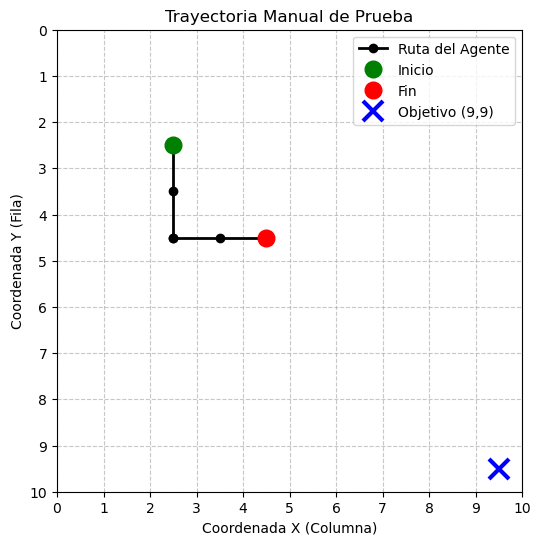

In [4]:
# ---------------------------------------------------------
# ¡Probemos el entorno!
# ---------------------------------------------------------
env = GridWorld(size=10)
obs, true_s = env.reset()

# Forzamos la ubicación de inicio a (2, 2) solo para esta demostración clara
env.agent_location = np.array([2, 2])
true_s = env.agent_location.copy()
obs = env._get_observation()

trajectory = [true_s.copy()]
action_names = {0: "Arriba", 1: "Abajo", 2: "Izquierda", 3: "Derecha", 4: "Pista"}

print("--- SIMULACIÓN DEL ENTORNO ---")
print(f"INICIO   | Estado real: {true_s} | Obs. ruidosa: {obs.round(1)} | Nivel de ruido: {env.noise_level}")

# Nos moveremos Abajo dos veces, pediremos una Pista, luego nos moveremos Derecha dos veces
actions_to_take = [1, 1, 4, 3, 3] 

for a in actions_to_take:
    obs, true_s = env.step(a)
    trajectory.append(true_s.copy())
    
    # ¡Obsérvese cómo la Observación se acerca mucho más al Estado Real tras la acción 'Pista'!
    action_str = action_names[a]
    print(f"Acción: {action_str:<10} | Estado real: {true_s} | Obs. ruidosa: {obs.round(1)} | Nivel de ruido: {env.noise_level}")

# Trazamos la trayectoria que acabamos de recorrer
plot_trajectory(trajectory, grid_size=env.size, goal_location=env.goal_location, title='Trayectoria Manual de Prueba')


### La formulación de energía libre de un paso hacia atrás y hacia adelante

La VFE puede usarse como cuantificador retrospectivo de un paso hacia atrás, y la EFE puede usarse como cuenta prospectiva de un paso hacia adelante.

> **En lo que sigue, nos situaremos en el instante de tiempo $t$. Es decir, observamos $o_t$ como resultado de $s_t$ (que es desconocido), e inferimos $s_t$ tanto como origen de $o_t$ (predicción retrospectiva, o inferencia) que como resultado de $a_{t-1}$ (predicción, donde $a_{t-1}$ es conocida). Asumimos también que, en el instante $t$, $s_{t-1}$ es CONOCIDO.**

Por ejemplo:
- En $t=0$, observamos $o_0$ como resultado de $s_0$ (que es desconocido), e inferimos $s_0$ como origen de $o_0$ (inferencia). Luego tomamos $a_{0}$ para avanzar a $t=1$.

- En $t=1$, observamos $o_1$ como resultado de $s_1$ (que es desconocido), e inferimos $s_1$ tanto como origen de $o_1$ que como resultado de $a_{0}$. Luego tomamos $a_{1}$ para avanzar a $t=2$.

- Y así sucesivamente...

En otras palabras, $h=0$, y la notación adquiere este significado:
$$
\boxed{
\begin{aligned}
\underline{o} &\triangleq o_{t:t}\equiv o_{t} \\
\underline{a} &\triangleq a_{t-1:t-1} \equiv a_{t-1}\\
\bar{a} &\triangleq  a_{t:t} \equiv a_t\\
\bar{s} &\triangleq  s_{t+1:t+1} \equiv s_{t+1}\\
\bar{o} &\triangleq  o_{t+1:t+1} \equiv o_{t+1}\\
\end{aligned}
}
$$


### Las redes de prior, posterior y verosimilitud

**Habiendo ejecutado nuestra última acción $a_{t-1}$, queremos evaluar la complejidad y precisión de nuestro modelo generativo actual con respecto a la observación recibida, $o_t$, y respecto al estado que somos capaces de inferir, $s_t$**:

El funcional VFE retrospectivo de un paso resulta ser:
$$
\begin{aligned}
VFE & =  \underbrace{D_{KL} \left[\overbrace{q_{o_{t}}(s_t\mid a_{t-1})}^{\text{posterior aprox.}} || \overbrace{Q(s_t \mid a_{t-1})}^{\text{Prior}} \right]}_{\text{Complejidad}} - \overbrace{\underbrace{\mathbb{E}_{q_{o_{t}}(s_t\mid a_{t-1})}\left[ \ln \overbrace{Q(o_{t} \mid s_t)}^{\text{modelo de verosimilitud}} \right]}_{\text{Precisión}}}^{\text{qué tan probable es } o_t \text{ bajo el post. aprox.}} \\
\end{aligned}
$$

**Having done our last action $a_{t-1}$, we want to evaluate our current generative model's complexity and accuracy w.r.t. the observation we got, $o_t$, and the state we are actually able to infer, $s_t$**:

The one-step-back retrospective VFE functional turns to be:
$$
\begin{aligned}
VFE & =  \underbrace{D_{KL} \left[\overbrace{q_{o_{t}}(s_t\mid a_{t-1})}^{\text{approx. posterior}} || \overbrace{Q(s_t \mid a_{t-1})}^{\text{Prior}} \right]}_{\text{Complexity}} - \overbrace{\underbrace{\mathbb{E}_{q_{o_{t}}(s_t\mid a_{t-1})}\left[ \ln \overbrace{Q(o_{t} \mid s_t)}^{\text{likelihood model}} \right]}_{\text{Accuracy}}}^{\text{how likely  } o_t  \text{  is under appox. post.}} \\
\end{aligned}
$$

Nuestro posterior variacional, en cambio, se implementará mediante una red neuronal $\mathbf{q}_{\theta}(o_{t}, a_{t-1})$, parametrizada por $\theta$, cuya salida será el estado inferido $\hat{s}_{t}$:

$$
\boxed{
\begin{aligned}
\text{Red del Posterior Variacional:}\\
\hat{s}_{t} \leftarrow \mathbf{q}_{\theta}(o_{t}, a_{t-1})\\
\text{aprender} \quad \theta^* \quad \text{tal que}\quad \hat{s}_{t} \sim q_{o_{t}}(s_{t}\mid a_{t-1})\\
\end{aligned}
}
$$

La primera línea de este recuadro indica que $\hat{s}_{t}$ es una estimación o inferencia sobre el estado subyacente real del mundo, $s_{t}$, obtenida como salida de redes neuronales cuando estas reciben ciertas entradas.

La segunda línea es interesante porque nos dice que queremos aprender unos valores óptimos de los parámetros de la red $\theta^*$ tales que podamos asumir que sus salidas son equivalentes a _muestrear_ de la distribución que aproxima.

### Una nota sobre la suposición gaussiana

Antes de avanzar hacia el entrenamiento de estas redes, necesitamos tender un puente entre la matemática probabilísticas que hemos derivado y las redes neuronales que estamos a punto de programar.

¿Cómo calculamos la divergencia KL entre distribuciones de probabilidad abstractas cuando nuestras redes neuronales simplemente producen vectores de modo determinístico (tales como $\hat{s}_t$)?

El truco estándar en los Autoencoders Variacionales (VAEs) y en la Inferencia Activa Profunda es **asumir que nuestras distribuciones son gaussianas esféricas (isotrópicas)** con varianza fija (habitualmente una matriz de covarianza identidad $I$). Bajo esta suposición, las redes neuronales no necesitan producir una distribución de probabilidad completa; simplemente producen la **media** ($\mu$) de la gaussiana.

Gracias a esta suposición, la divergencia KL entre dos gaussianas de este tipo se simplifica matemáticamente a una distancia euclídea escalada (norma $L_2$) entre sus medias:

$$
D_{KL}[\mathcal{N}(\mu_1, I) \parallel \mathcal{N}(\mu_2, I)] = \frac{1}{2} \|\mu_1 - \mu_2\|_2^2
$$

¡Esta elegante propiedad es lo que nos permite traducir nuestros funcionales abstractos de Energía Libre en funciones de pérdida de Error Cuadrático Medio (MSE) directamente programables!

In [5]:
# Definamos nuestra Red del Posterior (\mathbf{q}_\theta)
# Toma la observación actual (o_t) y la acción previa (a_{t-1}) 
# e infiere la media del estado oculto (\hat{s}_t)

class PosteriorNet(nn.Module):
    def __init__(self, obs_dim=2, action_dim=5, state_dim=2, hidden_dim=64):
        super().__init__()
        # Concatenamos observación y acción como entrada
        self.fc1 = nn.Linear(obs_dim + action_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mean = nn.Linear(hidden_dim, state_dim) # Produce \hat{s}_t
        
    def forward(self, obs, action_one_hot):
        # Concatenar a lo largo de la dimensión de características
        x = torch.cat([obs, action_one_hot], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc_mean(x)
    

posterior_net = PosteriorNet().to(device)

print(r"¡Red del Posterior inicializada! Este es nuestro posterior variacional $\mathbf{q}_\theta(o_t, a_{t-1})$.")


¡Red del Posterior inicializada! Este es nuestro posterior variacional $\mathbf{q}_\theta(o_t, a_{t-1})$.


### Probando la Red del Posterior (Inferencia de Estado)

En nuestro `GridWorld`, el agente nunca ve sus coordenadas reales `(x, y)`. Solo recibe una lectura de GPS ruidosa (la observación $o_t$).

Para averiguar dónde está realmente, el agente actúa como un detective valiéndose de su **Red del Posterior** $\mathbf{q}_\theta(o_t, a_{t-1})$. Esta red combina dos pistas:
1. **Lo que acaba de ver** (la observación ruidosa $o_t$).
2. **Lo que acaba de hacer** (la acción previa $a_{t-1}$. Si el agente sabe que acaba de moverse "Derecha", ¡eso es una pista enorme sobre su ubicación actual!).


Tomemos una observación real de nuestro entorno, supongamos que acabamos de tomar una acción, y pasémoslas a la red.

*Nota de Deep Learning:* Las redes neuronales no pueden procesar fácilmente números categóricos (como `3` para "Derecha"). Si simplemente le pasamos un `3`, la red podría creer que "Derecha" es tres veces mayor que "Abajo" (`1`). Para evitar esto, convertimos la acción discreta en un **vector one-hot** (por ejemplo, la Acción 3 se convierte en `[0, 0, 0, 1, 0]`).


In [6]:
# 1. Configuremos un escenario concreto en nuestro GridWorld
env = GridWorld(size=10)
env.agent_location = np.array([5, 5])  # Forzamos el estado real a estar exactamente en (5, 5)
obs = env._get_observation()           # Obtenemos la lectura ruidosa del GPS (o_t)

# 2. Supongamos que nuestra última acción fue "Derecha" (índice de acción 3)
last_action = 3                        # (a_{t-1})

# 3. Preparamos las entradas para PyTorch
# Las redes neuronales esperan datos en "lotes", así que añadimos una dimensión extra con .unsqueeze(0)
# La forma del tensor pasa de una dimensión de dos valores [2] a dos dimensiones, la primera de longitud 1 y la segunda de longitud 2: [1, 2]
obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)

# Convertimos la acción entera en un vector one-hot
action_tensor = torch.tensor([last_action])
action_one_hot = F.one_hot(action_tensor, num_classes=env.action_space_size).float().to(device)

# 4. ¡Le pedimos a la Red del Posterior que adivine nuestro estado real!
with torch.no_grad(): # Usamos no_grad() porque solo estamos estimando, no entrenando
    guessed_state = posterior_net(obs_tensor, action_one_hot)

print("--- PRUEBA DE PERCEPCIÓN ---")
print(f"Estado real (oculto para el agente): {env.agent_location}")
print(r"Observación ruidosa $o_t$:",f"           {obs.round(2)}")
print(r"Última acción $a_{t-1}$:",f"            {last_action} (One-Hot: {action_one_hot.cpu().numpy()[0]})")
print(r"Estimación de la red $\hat{{s}}_t$:",f"  {guessed_state.cpu().numpy()[0].round(2)}")
print("-" * 23)
print("¿Ves lo mala que es la estimación de la red en este momento?")
print("¡Es porque los pesos son completamente aleatorios! Aún no la hemos entrenado.")
print("Para corregir esto, minimizaremos la Energía Libre Variacional (VFE).")

--- PRUEBA DE PERCEPCIÓN ---
Estado real (oculto para el agente): [5 5]
Observación ruidosa $o_t$:            [5.42 5.83]
Última acción $a_{t-1}$:             3 (One-Hot: [0. 0. 0. 1. 0.])
Estimación de la red $\hat{{s}}_t$:   [-0.08 -0.37]
-----------------------
¿Ves lo mala que es la estimación de la red en este momento?
¡Es porque los pesos son completamente aleatorios! Aún no la hemos entrenado.
Para corregir esto, minimizaremos la Energía Libre Variacional (VFE).


In [7]:
# Veamos otro ejemplo de la red del posterior en acción

# 1. Supongamos que acabamos de dar un paso en nuestro GridWorld
last_action = 3  # Nos movimos a la Derecha
env.agent_location = np.array([5, 5]) # El Estado Real (que el agente NO puede ver)
true_state = env.agent_location.copy()

# El agente recibe una observación ruidosa
noisy_obs = env._get_observation()

# 2. Preparamos los datos para PyTorch
# Debemos convertir nuestros arrays de numpy en Tensores de PyTorch y añadir una dimensión de "lote"
obs_tensor = torch.FloatTensor(noisy_obs).unsqueeze(0).to(device)  # Forma: [1, 2]

# Creamos el tensor para la acción y aplicamos la codificación One-Hot
action_tensor = torch.tensor([last_action]).to(device)
action_one_hot = F.one_hot(action_tensor, num_classes=env.action_space_size).float() # Forma: [1, 5]

print("--- ENTRADAS A LA RED ---")
print(f"Observación ruidosa (o_t): {obs_tensor.cpu().numpy()}")
print(f"Última acción One-Hot (a_{{t-1}}): {action_one_hot.cpu().numpy()}")

# 3. Le pedimos a la red que estime el estado real
# Usamos torch.no_grad() porque ahora solo estamos estimando, ¡no entrenando!
with torch.no_grad():
    inferred_state = posterior_net(obs_tensor, action_one_hot)

print("\n--- LOS RESULTADOS ---")
print(f"Estado real (oculto):             {true_state}")
print(r"Estimación de la red $\hat{{s}}_t$:",f" {inferred_state.cpu().numpy().round(2)}")

print("\n¡Fíjate lo mala que es la estimación de la red ahora mismo! Puede devolver coordenadas negativas o números enormes.")
print("Esto es porque los pesos de la red son completamente aleatorios. ¡Necesitamos entrenarla usando la pérdida de Complejidad de la VFE!")

--- ENTRADAS A LA RED ---
Observación ruidosa (o_t): [[4.7066007 4.9701614]]
Última acción One-Hot (a_{t-1}): [[0. 0. 0. 1. 0.]]

--- LOS RESULTADOS ---
Estado real (oculto):             [5 5]
Estimación de la red $\hat{{s}}_t$:  [[-0.09 -0.31]]

¡Fíjate lo mala que es la estimación de la red ahora mismo! Puede devolver coordenadas negativas o números enormes.
Esto es porque los pesos de la red son completamente aleatorios. ¡Necesitamos entrenarla usando la pérdida de Complejidad de la VFE!


### El paso retrospectivo

Supongamos por un momento que estamos en el instante $t-2$; ejecutamos una acción $a_{t-2}$ y avanzamos al instante $t-1$. En ese momento, el estado $s_{t-2}$ *se revela*, se vuelve visible: esa es nuestra suposición.



> **Supongamos entonces que ejecutamos una acción $a_{t-1}$ y avanzamos al instante $t$, momento en que el estado $s_{t-1}$ se revela.**
>
> Esto significa que, en (cualquier) instante $t$, podríamos usar $o_{t-1}$ y $a_{t-2}$ para construir una estimación de $s_{t-1}$, llamémosla $\hat{s}_{t-1}$, a partir del posterior aproximado. Sabiendo que ahora tenemos el $s_{t-1}$ real, podemos usarlo como la media empírica de nuestro prior $Q(s_{t-1} \mid a_{t-2})$.
>
> Aplicando la suposición gaussiana que acabamos de discutir, podemos calcular el término de complejidad de la VFE como la distancia $L_2$ escalada entre la salida de nuestra red del posterior ($\hat{s}_{t-1}$) y el estado real revelado ($s_{t-1}$):
> $$
  \begin{aligned}
  \hat{s}_{t-1} &\leftarrow \mathbf{q}_{\theta}(o_{t-1}, a_{t-2}) \quad &\text{(media del posterior aprox. } q\text{)}\\
  {s}_{t-1} &\leftarrow \text{estado real revelado} \quad &\text{(media del prior } Q\text{)}\\
  &\implies\\
  \underbrace{D_{KL} \left[{q_{o_{t-1}}(s_{t-1}\mid a_{t-2})} \parallel {Q(s_{t-1} \mid a_{t-2})} \right]}_{\text{término de Complejidad de la VFE}} &\approx \frac{1}{2} ||\hat{s}_{t-1} - s_{t-1} ||^2_2 \\
  \end{aligned}
  $$

Sí, lo sé: no podemos hacer esto para todo $t$, sino solo a partir de $t=2$ (o desde $t=1$ si creamos una acción fantasma $a_{-1}$). Pero no hay que preocuparse: desde $t=2$ en adelante, hay mucho tiempo para aprender :)

### Corrigiendo las Estimaciones: Minimizando la VFE con Descenso de Gradiente

El resumen de lo que acabamos de decir es el siguiente: ¿cómo hacemos que nuestra red sea más inteligente? Esperamos a que el entorno "revele" el estado real y luego miramos hacia atrás en el tiempo.

Si la red estimó `[0.5, 2.1]` pero el estado real era `[1.0, 0.0]`, calculamos la diferencia. Como aprendimos en la sección matemática, bajo la suposición gaussiana, la **Complejidad de la VFE** se reduce a la mitad del Error Cuadrático Medio (MSE) entre la estimación y el estado real.



Vamos a dejar que el agente tome **10.000 acciones aleatorias** (deambulando sin rumbo por la cuadrícula).

En cada paso, el agente:
1. Mirará su GPS ruidoso (`obs_t`) y recordará su último movimiento (`last_action`).
2. Hará una estimación de su ubicación real (`guessed_state`).
3. Permitirá que el entorno "revele" la ubicación real (`true_s_t`).
4. Calculará la **Complejidad de la VFE** (el error entre la estimación y la verdad).
5. Usará la **Retropropagación** para actualizar su cerebro.

Como los sensores son ruidosos, la pérdida oscilará un poco, pero con el tiempo deberíamos ver una tendencia claramente descendente a medida que la red aprende a filtrar el ruido.


Iniciando entrenamiento por exploración aleatoria para la Red del Posterior...

Paso 200  | Objetivo: [2 4] | Estimación: [1.7 4. ] | Pérdida: 0.0176
Paso 400  | Objetivo: [3 5] | Estimación: [4.2 5. ] | Pérdida: 0.0148
Paso 600  | Objetivo: [7 8] | Estimación: [6.3 7.8] | Pérdida: 0.0381
Paso 800  | Objetivo: [1 5] | Estimación: [1.1 6.5] | Pérdida: 0.0710
Paso 1000 | Objetivo: [6 0] | Estimación: [ 6.8 -0. ] | Pérdida: 0.0058
Paso 1200 | Objetivo: [7 3] | Estimación: [7.2 2.9] | Pérdida: 0.0086
Paso 1400 | Objetivo: [1 1] | Estimación: [2.1 0.9] | Pérdida: 0.0065
Paso 1600 | Objetivo: [5 6] | Estimación: [4.7 5.2] | Pérdida: 0.0309
Paso 1800 | Objetivo: [4 1] | Estimación: [4.2 0. ] | Pérdida: 0.0143
Paso 2000 | Objetivo: [5 1] | Estimación: [5.3 0.1] | Pérdida: 0.0171
Paso 2200 | Objetivo: [0 0] | Estimación: [0.1 1. ] | Pérdida: 0.0025
Paso 2400 | Objetivo: [0 5] | Estimación: [-0.1  5.3] | Pérdida: 0.0174
Paso 2600 | Objetivo: [3 4] | Estimación: [3.  2.8] | Pérdida: 0.0089
Paso 2

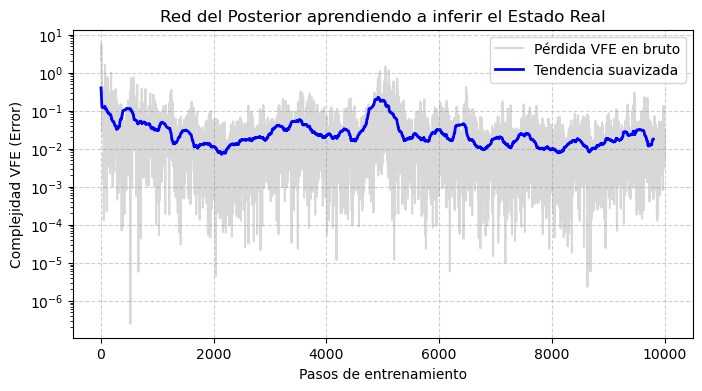


¡Entrenamiento completado! La tendencia descendente demuestra que la red aprendió a filtrar el ruido de los sensores.


In [8]:
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Reiniciamos para asegurarnos de empezar con un cerebro nuevo y sin entrenamiento
posterior_net = PosteriorNet(obs_dim=2, action_dim=5, state_dim=2).to(device)
posterior_optimizer = optim.Adam(posterior_net.parameters(), lr=0.002)

# 2. Reiniciamos el entorno
env = GridWorld(size=10)
obs, true_s = env.reset()
last_action = 0 # Acción inicial arbitraria

# Guardamos aquí las pérdidas para graficarlas después
vfe_losses = []

print("Iniciando entrenamiento por exploración aleatoria para la Red del Posterior...\n")

# 3. El Bucle de Entrenamiento (10.000 pasos de deambulación aleatoria)
for step in range(1, 10001):

    # --- A. Preparar datos para PyTorch ---
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
    true_s_tensor = torch.FloatTensor(true_s).unsqueeze(0).to(device)

    # Codificación One-Hot de la última acción
    action_tensor = torch.tensor([last_action])
    action_one_hot = F.one_hot(action_tensor, num_classes=env.action_space_size).float().to(device)

    # --- B. Pasada hacia adelante (Estimar el estado) ---
    guessed_state = posterior_net(obs_tensor, action_one_hot)

    # --- C. Calcular la Complejidad de la VFE (MSE escalado por 0.5) ---
    vfe_complexity = 0.5 * F.mse_loss(guessed_state, true_s_tensor)

    # --- D. Retropropagación (Actualizar los pesos) ---
    posterior_optimizer.zero_grad()
    vfe_complexity.backward()
    posterior_optimizer.step()

    # Guardamos la pérdida para graficarla
    vfe_losses.append(vfe_complexity.item())

    # --- E. Interactuar con el Entorno ---
    # Tomamos una acción completamente ALEATORIA para explorar la cuadrícula
    action = np.random.choice(env.action_space_size)
    next_obs, next_true_s = env.step(action)

    # Actualizamos nuestras variables para la siguiente iteración
    obs = next_obs
    true_s = next_true_s
    last_action = action

    # Imprimimos el progreso cada 200 pasos
    if step % 200 == 0:
        guess_print = guessed_state.detach().cpu().numpy()[0].round(1)
        print(f"Paso {step:<4} | Objetivo: {true_s} | Estimación: {guess_print} | Pérdida: {vfe_complexity.item():.4f}")

# 4. ¡Graficamos la Convergencia!
# Dado que el entorno es naturalmente ruidoso, la pérdida salta bastante.
# Calcularemos una "Media Móvil" para que la curva de aprendizaje sea más fácil de visualizar:
def moving_average(data, window_size=200):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


smoothed_losses = moving_average(vfe_losses)

plt.figure(figsize=(8, 4))
plt.plot(vfe_losses, alpha=0.3, color='gray', label='Pérdida VFE en bruto')
plt.plot(smoothed_losses, color='blue', linewidth=2, label='Tendencia suavizada')
plt.title("Red del Posterior aprendiendo a inferir el Estado Real")
plt.xlabel("Pasos de entrenamiento")
plt.ylabel("Complejidad VFE (Error)")
plt.legend()
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n¡Entrenamiento completado! La tendencia descendente demuestra que la red aprendió a filtrar el ruido de los sensores.")


> *"En este tutorial podríamos haber incluido un modelo de verosimilitud $Q(o_t \mid s_t)$ y haberlo optimizado usando el término de Precisión de la VFE (actuando esencialmente como un Decodificador). Pero no lo haremos.*
>
> *¿Por qué? En deep learning, obligar a un agente a reconstruir observaciones de alta dimensión (como píxeles en bruto) suele hacer que el espacio latente desperdicie capacidad modelando ruido de fondo irrelevante —el clásico 'problema de los distractores'. Al saltarnos la verosimilitud generativa y centrarnos únicamente en el término de Complejidad de la VFE y en la EFE, forzamos nuestras representaciones latentes para que sean estrictamente centradas en la tarea y en la dinámica. Estamos haciendo Inferencia Activa mediante predicción hacia adelante en el espacio latente, en lugar de reconstrucción sensorial."*

Hasta ahora hemos hablado de tomar acciones en los instantes $t-2$, $t-1$ y, en general, en el instante $t$. Pero surge la pregunta: ¿qué acción $a_t$ tomar en cada momento? Responderemos esa pregunta y aplicaremos el paradigma de inferencia activa en la siguiente sección.

### El modelo de policy

**Nos centramos ahora en el paso prospectivo: elegir nuestra próxima acción $a_t$.**

Usaremos una red neuronal llamada red de policy que nos dirá en cada momento qué acción tomar. Esta red está pensada para ayudarnos a elegir la mejor acción posible, concretamente aquella que minimice el funcional de Energía Libre Esperada (EFE).




En lugar de devolver directamente una acción fija, la red de política $\mathbf{Q}_{\phi}(s_t)$, parametrizada por $\phi$, producirá una **distribución de probabilidad** sobre todas las acciones posibles dado el estado actual (inferido) $s_t$. Llamemos $\pi_t$ a esta distribución predecida. Luego *muestreamos* nuestra próxima acción $a_t$ a partir de ella.

Este es nuestro modelo de policy, nuestra forma de actuar:

$$
\boxed{
\begin{aligned}
&\text{Red de Política:}\\
\pi_t &= \mathbf{Q}_{\phi}(s_t) \quad &&\text{(Devuelve probabilidades de acción)}\\
a_t &\sim \pi_t \quad &&\text{(Muestreamos la acción a tomar)}\\
&\text{aprender} \quad \phi^* \quad \text{tal que} \quad &&\pi_t \approx \sigma[-\zeta \mathbf{G}_{\psi}(s_t, \mathbf{a})]
\end{aligned}
}\tag{PN}
$$


Un momento. ¿Qué es $\sigma[-\zeta \mathbf{G}_{\psi}(s_t, \mathbf{a})]$?

A esto lo llamamos **distribución de Gibbs**. Desglosémosla:

- $\sigma[\cdot]$ es el **operador Softmax**. Transforma un *conjunto* de entradas numéricas arbitrarias en una distribución de probabilidad válida (todos los valores suman 1, formando un símplex).

- $\zeta$ (zeta) es un **hiperparámetro de precisión**. Es un escalar que determina la polarización o entropía de la distribución de probabilidad resultante. Un $\zeta$ muy alto hace al agente muy determinista y codicioso (explotando la mejor EFE), mientras que un $\zeta$ bajo suaviza la distribución, haciendo al agente más aleatorio y exploratorio.

- $\mathbf{G}_{\psi}(s_t, \mathbf{a})$ denota un vector con los valores aproximados de la EFE para cada acción posible $a \in \mathbf{a}$. Y sí, lo has adivinado: ¡ese vector es la salida de *otra* red neuronal!

- **El signo menos es crucial.** Recuerda que la EFE es un *coste* o una *energía* que queremos **minimizar**. Al negarla antes de aplicar el Softmax, garantizamos que las acciones con la *menor* Energía Libre Esperada reciban la *mayor* probabilidad de ser elegidas.

In [9]:
# Definamos ahora los "cerebros prospectivos": las Redes de Política y Crítico

class PolicyNet(nn.Module):
    def __init__(self, state_dim=2, num_actions=5, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        # Devuelve logits (puntuaciones en bruto) para cada acción posible
        self.fc_logits = nn.Linear(hidden_dim, num_actions)
        
    def forward(self, state):
        x = F.relu(self.fc1(state))
        logits = self.fc_logits(x)
        return logits # Devolvemos logits; aplicaremos el Softmax (Gibbs) después

In [10]:
# =============================================================================
# EFE PROXY PARA EL ENTRENAMIENTO PEDAGÓGICO DE LA POLÍTICA
# =============================================================================
# Antes de introducir el Crítico aprendido (que estimará la EFE real),
# creamos un **proxy artesanal** que ya captura las dos motivaciones centrales:
#   1. Pragmática: "acercarse al objetivo (9,9)"
#   2. Epistémica:  "usar la acción Pista para reducir el ruido del sensor"
#
# Este proxy nos permite entrenar la Red de Política *de forma independiente*
# para ver cómo la distribución de Gibbs (softmax[-ζ·EFE]) produce naturalmente
# un comportamiento orientado al objetivo y curioso, sin aprendizaje por
# diferencia temporal todavía.
#
# (Reemplazaremos este proxy con el Crítico aprendido en la siguiente celda.)

def compute_proxy_efe(inferred_state, goal_location):
    """
    Devuelve un vector de valores EFE proxy para cada acción (0-4).
    Menor = mejor (minimizaremos la EFE).

    Componente pragmática: distancia esperada al objetivo tras el movimiento
    Componente epistémica: bonificación fuerte (coste negativo) para la acción Pista
    """
    inferred = np.array(inferred_state)
    goal = np.array(goal_location)

    # Desplazamientos deterministas de movimiento (idénticos al entorno)
    deltas = np.array([
        [-1.,  0.],  # 0 = Arriba
        [ 1.,  0.],  # 1 = Abajo
        [ 0., -1.],  # 2 = Izquierda
        [ 0.,  1.],  # 3 = Derecha
        [ 0.,  0.]   # 4 = Pista (sin movimiento)
    ])

    proxy_efe = np.zeros(5)

    for a in range(5):
        # Simulamos cuál sería el *próximo* estado inferido (movimiento determinista)
        next_est = np.clip(inferred + deltas[a], 0, 9)

        # === Componente pragmática (búsqueda del objetivo) ===
        # Penalización positiva = mayor cuando estamos lejos de (9,9)
        pragmatic = 0.5 * np.sum((next_est - goal)**2)

        # === Componente epistémica (curiosidad / ganancia de información) ===
        # La Pista tiene un coste negativo fuerte (QUEREMOS tomarla a veces)
        # Los movimientos tienen bonificación epistémica cero en este proxy simple
        epistemic = -5.0 if a == 4 else 0.0

        proxy_efe[a] = pragmatic + epistemic

    return proxy_efe

Entrenando la Red de Política con EFE Proxy (pragmática + epistémica)...

Paso 200   | EFE Proxy: [46.28 39.17 46.81 34.25 37.22] | Mejor acción: 3 | Pérdida política: 0.0001
Paso 400   | EFE Proxy: [ 9.81  7.87 12.81  4.87  3.34] | Mejor acción: 4 | Pérdida política: 0.0008
Paso 600   | EFE Proxy: [46.33 39.02 47.17 34.25 37.17] | Mejor acción: 3 | Pérdida política: 0.0000
Paso 800   | EFE Proxy: [26.19 22.62 31.08 17.72 18.9 ] | Mejor acción: 3 | Pérdida política: 0.0030
Paso 1000  | EFE Proxy: [20.07 11.61 19.42 12.26 10.34] | Mejor acción: 4 | Pérdida política: 0.0020
Paso 1200  | EFE Proxy: [ 4.32  1.55  4.65  1.21 -2.57] | Mejor acción: 4 | Pérdida política: 0.0000
Paso 1400  | EFE Proxy: [22.49 20.5  27.9  15.09 15.99] | Mejor acción: 3 | Pérdida política: 0.0068
Paso 1600  | EFE Proxy: [59.1  45.68 60.05 44.72 46.89] | Mejor acción: 3 | Pérdida política: 0.1131
Paso 1800  | EFE Proxy: [ 2.87  0.38  2.45  0.77 -3.88] | Mejor acción: 4 | Pérdida política: 0.0205
Paso 2000  | EFE 

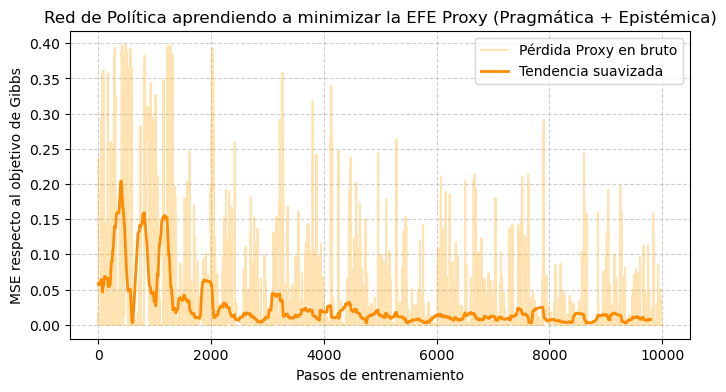


¡La Red de Política ya está entrenada con el proxy! Prefiere los movimientos hacia (9,9) y ocasionalmente toma la acción Pista (impulso epistémico).
En la siguiente celda reemplazaremos este proxy con la Red Crítico aprendida.


In [11]:
# =============================================================================
# ENTRENAMIENTO INDEPENDIENTE DE LA POLÍTICA CON EFE PROXY
# =============================================================================
# Dejamos al agente deambular aleatoriamente mientras la Red de Política
# se supervisa para ajustarse a la distribución de Gibbs del EFE proxy.
# Esta es exactamente la misma lógica que se usará después con el Crítico aprendido.

zeta_proxy = 2.0
policy_net = PolicyNet(state_dim=2, num_actions=5).to(device)
policy_optimizer = optim.Adam(policy_net.parameters(), lr=0.01)

# Reiniciamos el entorno
env = GridWorld(size=10)
obs, true_s = env.reset()
last_action = 0

proxy_losses = []
print("Entrenando la Red de Política con EFE Proxy (pragmática + epistémica)...\n")

for step in range(1, 10001):

    # 1. Inferimos el estado actual con la Red del Posterior ya entrenada
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
    action_oh = F.one_hot(torch.tensor([last_action]), num_classes=5).float().to(device)
    with torch.no_grad():
        inferred_state = posterior_net(obs_tensor, action_oh).cpu().numpy()[0]

    # 2. Calculamos el vector EFE proxy (la "señal docente")
    proxy_efe_vec = compute_proxy_efe(inferred_state, env.goal_location)
    proxy_efe_tensor = torch.FloatTensor(proxy_efe_vec).unsqueeze(0).to(device)

    # 3. Probabilidades objetivo = distribución de Gibbs del proxy
    target_probs = F.softmax(-zeta_proxy * proxy_efe_tensor, dim=-1)

    # 4. Probabilidades actuales de la política 
    state_tensor = torch.FloatTensor(inferred_state).unsqueeze(0).to(device)
    logits = policy_net(state_tensor)
    current_probs = F.softmax(logits, dim=-1)

    # 5. Pérdida = hacer que la política se ajuste a la distribución de Gibbs del proxy
    policy_loss = F.mse_loss(current_probs, target_probs)

    policy_optimizer.zero_grad()
    policy_loss.backward()
    policy_optimizer.step()

    proxy_losses.append(policy_loss.item())

    # 6. Tomamos una acción aleatoria (exploración pura del espacio de estados)
    action = np.random.choice(env.action_space_size)
    obs, true_s = env.step(action)
    last_action = action

    if step % 200 == 0:
        best_action = np.argmin(proxy_efe_vec)
        print(f"Paso {step:<5} | "
              f"EFE Proxy: {proxy_efe_vec.round(2)} | "
              f"Mejor acción: {best_action} | "
              f"Pérdida política: {policy_loss.item():.4f}")

# =============================================================================
# Graficamos la convergencia
# =============================================================================
smoothed_proxy = moving_average(proxy_losses, window_size=200)

plt.figure(figsize=(8, 4))
plt.plot(proxy_losses, alpha=0.3, color='orange', label='Pérdida Proxy en bruto')
plt.plot(smoothed_proxy, color='darkorange', linewidth=2, label='Tendencia suavizada')
plt.title("Red de Política aprendiendo a minimizar la EFE Proxy (Pragmática + Epistémica)")
plt.xlabel("Pasos de entrenamiento")
plt.ylabel("MSE respecto al objetivo de Gibbs")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n¡La Red de Política ya está entrenada con el proxy! Prefiere los movimientos hacia (9,9) "
      "y ocasionalmente toma la acción Pista (impulso epistémico).")
print("En la siguiente celda reemplazaremos este proxy con la Red Crítico aprendida.")

### La red crítico

El "valor" de una acción es un concepto bien establecido en el aprendizaje por refuerzo (RL), con el que se evalúa la próxima acción a tomar. Habitualmente se habla de valorar "políticas" más que acciones individuales. En la jerga del RL, las políticas son funciones que devuelven acciones dado un estado; en la jerga de la Inferencia Activa, las políticas son simplemente secuencias de acciones. En cualquier caso, vamos a elegir la SIGUIENTE acción, $a_{t}$, es decir, nuestro horizonte de planificación será simplemente $h=1$. ¿Y cuál será la puntuación de valoración? Sí, lo has adivinado: la EFE.

Crearemos una red neuronal que aproxime la EFE para cada acción $a \in \mathbf{a}$. Siguiendo las convenciones de nomenclatura del RL, llamaremos a este personaje la _red crítico_ $\mathbf{G}_{\psi}(\mathbf{a},s_{t})$, ya que estimará la EFE asociada a cada posible próxima acción $a_{t}$ dado el estado actual (inferido), $s_{t}$. Los parámetros de esta red neuronal se denotan por $\psi$.


In [12]:
class CriticNet(nn.Module):
    def __init__(self, state_dim=2, num_actions=5, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc_efe = nn.Linear(hidden_dim, num_actions)
        
    def forward(self, state):
        x = F.relu(self.fc1(state))
        return self.fc_efe(x)
    

critic_net = CriticNet().to(device)
print("¡Red de Policy (Q_phi) y Red Crítico (G_psi) inicializadas!")

¡Red de Policy (Q_phi) y Red Crítico (G_psi) inicializadas!


Así pues, creamos esta red neuronal y la inicializamos con valores arbitrarios. A continuación optimizaremos esos valores usando nuestro paradigma de aprendizaje favorito (por ahora, supongamos el descenso de gradiente estocástico). Por encima de esa dinámica de aprendizaje, la forma macro-estructural de optimizar al señor $\mathbf{G}$ será a través de lo que se denomina "aprendizaje por diferencia temporal" (_temporal difference learning_): usaremos alguna retroalimentación *real* de un paso desde el mundo, le añadiremos nuestra estimación actual —basada en $\mathbf{G}$— del resto de pasos futuros, y usaremos ese conjunto como si fuera "la verdad"; luego optimizaremos nuestro $\mathbf{G}$ para ajustarse a esa "verdad". (Esto es lo que significa _bootstrapping_: como levantarse del suelo tirando uno mismo de sus propias botas.) En cualquier caso, resulta funcionar:

$$
\boxed{
\begin{aligned}
&\quad \quad \text{La Red Crítico}\\
\underbrace{\mathcal{G}(a_{t}, s_{t})}_{\text{EFE de referencia}} \triangleq & \underbrace{\bar{\mathcal{G}}(a_{t}, s_{t})}_{\text{Retroalimentación real}}  + \underbrace{\gamma}_{\text{``factor de descuento"}} \cdot \min \underbrace{ \left[  \hat{\mathbf{G}}_{\hat{\psi}}(\mathbf{a}, s_{t+1}) \right]  }_{\text{Estimación EFE del crítico}}\\\\
\text{aprender}  &\quad \psi^* \quad \text{tal que:} \quad {\mathbf{G}}_{{\psi}^*}(a_{t}, s_{t}) \to \mathcal{G}(a_{t}, s_{t})
\end{aligned}
}
$$

Pero espera, ¿qué es este $\bar{\mathcal{G}}(a_{t}, s_{t})$? Es precisamente un valor de la EFE calculado a posteriori en un único paso. Tomamos una acción en el instante $t$, vemos qué ocurre... y nos preguntamos: ¿cuál fue la energía libre de esa única acción?

Recordemos la formulación de la EFE de un paso:
$$
\begin{aligned}
EFE \triangleq - \underbrace{\mathbb{E}_{Q( o_{t+1} | a_t)}\left[D_{KL}\left[Q(s_{t+1} | o_{t+1} , a_t) ||q_{o_{t+1}}(s_{t+1}\mid a_t) \right]\right]}_{\text{Ganancia epistémica de un paso}} - \underbrace{\mathbb{E}_{Q( o_{t+1}| a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]}_{\text{Ganancia pragmática de un paso}}\\\\
\end{aligned}
$$

Usamos esa estructura para calcular nuestro $\bar{\mathcal{G}}(a_{t}, s_{t})$:
$$
\begin{aligned}
\\
&\underbrace{\bar{\mathcal{G}}(a_{t}, s_{t})}_{\text{retroalimentación de un paso}}\triangleq \\
& \quad \quad - \underbrace{\mathbb{E}_{Q( o_{t+1} | a_t)}\left[D_{KL}\left[Q(s_{t+1} | o_{t+1} , a_t) ||q_{o_{t+1}}(s_{t+1}\mid a_t) \right]\right]}_{\text{ganancia epistémica de un paso}} \\
& \quad \quad - \underbrace{\mathbb{E}_{Q( o_{t+1}| a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]}_{\text{ganancia pragmática de un paso}}\\
\end{aligned}
$$

#### La ganancia epistémica one-step

No implementaremos la ganancia epistémica en el instante $t$ porque no conocemos el posterior real $Q(s_{t+1} \mid o_{t+1} , a_t)$. De hecho, tampoco conocemos el posterior real en el instante $t$, $Q(s_{t} \mid o_{t} , a_{t-1})$.

Sin embargo, en el instante $t$, el estado $s_{t-1}$ es conocido y puede usarse como estimación puntual del posterior real, tal como hicimos para la VFE.

**Antes, para la Complejidad de la VFE, hicimos:**
$$
\begin{aligned}
\hat{s}_{t-1} &\leftarrow \mathbf{q}_{\theta}(o_{t-1}, a_{t-2}) \quad &\text{(media del posterior aprox. } q\text{)}\\
{s}_{t-1} &\leftarrow \text{estado real revelado} \quad &\text{(media del prior } Q\text{)}\\
&\implies\\
\underbrace{D_{KL} \left[{q_{o_{t-1}}(s_{t-1}\mid a_{t-2})} \parallel {Q(s_{t-1} \mid a_{t-2})} \right]}_{\text{término de Complejidad de la VFE}} &\approx \frac{1}{2} ||\hat{s}_{t-1} - s_{t-1} ||^2_2 \\
\end{aligned}
$$

**Ahora, para la Ganancia Epistémica, hacemos:**
Aplicando la misma suposición gaussiana, la divergencia KL dentro de la expectativa se traduce en una distancia $L_2$ escalada:
$$
\underbrace{\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[D_{KL}\left[Q(s_{t-1} \mid o_{t-1} , a_{t-2}) \parallel q_{o_{t-1}}(s_{t-1}\mid a_{t-2}) \right]\right]}_{\text{ganancia epistémica de un paso}} \approx \mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2\right]
$$

¡Nótese la diferencia en los argumentos de la divergencia KL! En la complejidad de la VFE era $q \parallel Q$, pero aquí en la ganancia epistémica se invierte: $Q \parallel q$. Además, la distribución verdadera aquí es el posterior $Q(s \mid o,a)$, no el prior $Q(s \mid a)$.

Sin embargo, como la distancia euclídea es simétrica ($\|A - B\|_2^2 = \|B - A\|_2^2$), la suposición gaussiana nos regala una bella conveniencia matemática: la divergencia invertida se reduce exactamente al mismo formato de Error Cuadrático Medio.

Dado que en realidad *vimos* la observación $o_{t-1}$, podemos aproximar la expectativa exterior usando esta única muestra (aproximación de Monte Carlo). Simplemente evaluamos el término interior sin el operador de expectativa:

$$\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2\right] \approx \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2$$

En resumen:

$$
\boxed{
  \begin{aligned}
  &\text{Ganancia epistémica de un paso aproximada (de } t-1 \text{ a } t \text{):}\\
  &\hat{s}_{t-1} =  \mathbf{q}_{\theta}(o_{t-1}, a_{t-2})\\
&\underbrace{\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[D_{KL}\left[Q(s_{t-1} \mid o_{t-1} , a_{t-2}) \parallel q_{o_{t-1}}(s_{t-1}\mid a_{t-2}) \right]\right]}_{\text{ganancia epistémica de un paso}}\approx \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1}\right\|_2^2
\end{aligned}
}
$$

#### La ganancia pragmática one-step

Este es nuestro término pragmático: la expectativa del log-likelihood de las observaciones futuras bajo nuestra distribución vital/objetivo $\mathbf{C}$:

$$
\mathbb{E}_{Q( o_{t+1} \mid a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]
$$

Para entrenar nuestra red crítico usando retroalimentación real, evaluamos esta expectativa de forma retrospectiva, mirando la transición de $t-1$ a $t$. La expectativa se convierte en:

$$
\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \ln Q(o_{t-1} \mid \mathbf{C}) \right]
$$


Como en realidad ejecutamos la acción y observamos $o_{t-1}$, podemos nuevamente usar la "aproximación de Monte Carlo de una sola muestra" para eliminar el operador de expectativa:

$$\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \ln Q(o_{t-1} \mid \mathbf{C}) \right]
 \approx  \ln Q(o_{t-1} \mid \mathbf{C})
$$

¿Cómo calculamos esta log-probabilidad normativa? La imponemos como un desiderátum. Supongamos que tenemos una observación objetivo deseada concreta $o^*$. Si aplicamos nuestra confiable suposición gaussiana, modelamos la distribución vital $Q(o \mid \mathbf{C})$ como una gaussiana centrada en $o^*$.

**De forma crucial, el log-likelihood de una gaussiana es proporcional a la distancia al cuadrado con signo *negativo*:**

$$
\ln Q(o_{t-1} \mid \mathbf{C}) \approx -\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2
$$

*(¡Nótese el signo negativo! Esto tiene sentido intuitivo: cuanto más se aleja la observación de nuestro objetivo $o^*$, más negativa se vuelve su log-probabilidad.)*


$$
\boxed{
  \begin{aligned}
  &\text{Ganancia pragmática de un paso aproximada:}\\
&\ln Q(o_{t-1} \mid \mathbf{C}) \approx -\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2
\end{aligned}
}
$$

#### Juntando todo: la retroalimentación EFE de un paso

Ensamblemos la EFE esperada real de un paso, $\bar{\mathcal{G}}$. Recordemos la fórmula general:
$$ EFE \triangleq - \text{Ganancia Epistémica} - \text{Ganancia Pragmática} $$


Reindexamos genéricamente a la transición de $t$ a $t+1$ (evaluando la acción $a_t$) y sustituimos nuestras aproximaciones gaussianas:
- **Ganancia Epistémica**: $\approx \frac{1}{2} \left\| s_{t+1} - \hat{s}_{t+1} \right\|_2^2$
- **Ganancia Pragmática**: $\approx -\frac{1}{2} \left\| o_{t+1} - o^* \right\|_2^2$

$$
\boxed{
\begin{aligned}
&\text{Retroalimentación EFE de un paso aproximada para la acción } a_t:\\
&\bar{\mathcal{G}}(a_t, s_t) \approx - \underbrace{\frac{1}{2} \left\| s_{t+1} - \hat{s}_{t+1} \right\|_2^2}_{\text{Curiosidad (minimizar EFE para explorar)}} + \underbrace{\frac{1}{2} \left\| o_{t+1} - o^* \right\|_2^2}_{\text{Búsqueda del objetivo (minimizar EFE para explotar)}}
\end{aligned}
}
$$

Fíjate en lo que ocurre con los signos negativos: el doble negativo sobre la ganancia pragmática la convierte en una *penalización de distancia positiva*.

Como nuestro agente quiere **minimizar** la EFE, esta ecuación final equilibra perfectamente dos impulsos: quiere que el error epistémico sea *grande* (impulsando la exploración/curiosidad) mientras quiere que la distancia al objetivo sea *pequeña* (impulsando la explotación/pragmatismo).

### Entrenando al Crítico: aprendiendo a predecir el futuro

Pongamos ahora nuestra `CriticNet` en el entorno. Su trabajo es predecir la **Energía Libre Esperada (EFE)** de cada acción *antes* de tomarla.

Para entrenarlo, dejaremos de nuevo que la red de política ya entrenada elija acciones durante 2000 pasos. En cada paso, calculamos la EFE de "referencia" basándonos en lo que realmente ocurrió:
1. **Ganancia Epistémica:** ¿Estimó correctamente nuestra `PosteriorNet` el nuevo estado, o se sorprendió por el ruido del sensor? (Curiosidad)
2. **Penalización Pragmática:** ¿A qué distancia está la nueva observación de la `Ubicación Objetivo (9, 9)`? (Explotación)
3. **Bootstrapping (Aprendizaje TD):** Sumamos la EFE de un paso a la EFE *futura* estimada por nuestra `Red Crítico Objetivo`.

*Nota de Deep Learning:* En el aprendizaje por Diferencia Temporal (TD), la "verdad" que intentamos ajustar cambia continuamente a medida que la red mejora. Para evitar que la red persiga su propia cola, usamos una **Red Objetivo** congelada para estimar el futuro, y solo actualizamos esta red objetivo cada 100 pasos. ¡De hecho verás esto en el gráfico de pérdida como "picos" periódicos!

Iniciando entrenamiento por exploración aleatoria para la Red Crítico...

Paso 100  | EFE 1 paso: 5.92 | EFE predicha: 4.81 | EFE objetivo: 4.43 | Pérdida: 0.15
Paso 200  | EFE 1 paso: 5.74 | EFE predicha: 5.50 | EFE objetivo: 5.16 | Pérdida: 0.12
Paso 300  | EFE 1 paso: 6.16 | EFE predicha: 6.00 | EFE objetivo: 5.60 | Pérdida: 0.16
Paso 400  | EFE 1 paso: 6.17 | EFE predicha: 5.94 | EFE objetivo: 5.63 | Pérdida: 0.10
Paso 500  | EFE 1 paso: 6.01 | EFE predicha: 6.01 | EFE objetivo: 5.48 | Pérdida: 0.28
Paso 600  | EFE 1 paso: 6.14 | EFE predicha: 5.63 | EFE objetivo: 5.62 | Pérdida: 0.00
Paso 700  | EFE 1 paso: 6.33 | EFE predicha: 5.93 | EFE objetivo: 5.84 | Pérdida: 0.01
Paso 800  | EFE 1 paso: 6.43 | EFE predicha: 5.68 | EFE objetivo: 5.97 | Pérdida: 0.08
Paso 900  | EFE 1 paso: 6.14 | EFE predicha: 5.75 | EFE objetivo: 5.70 | Pérdida: 0.00
Paso 1000 | EFE 1 paso: 6.15 | EFE predicha: 5.82 | EFE objetivo: 5.74 | Pérdida: 0.01
Paso 1100 | EFE 1 paso: 6.75 | EFE predicha: 5.86 | EFE 

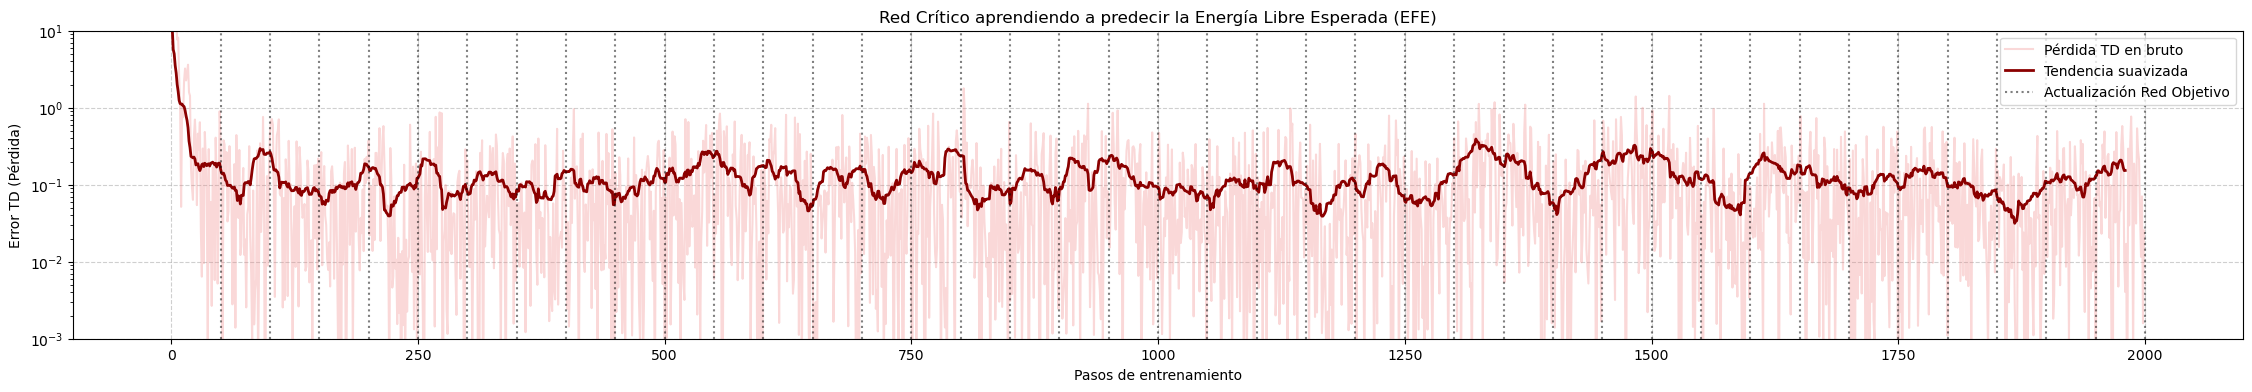


¡Entrenamiento completado! Nótense los 'picos' en la pérdida cada vez que se actualiza la Red Objetivo (líneas punteadas).
¡Esto demuestra que el agente ajusta activamente sus predicciones sobre el futuro!


In [13]:
import copy

# 1. Reinicializamos el Crítico y su Objetivo
critic_net = CriticNet(state_dim=2, num_actions=5).to(device)
target_critic_net = copy.deepcopy(critic_net)
target_critic_net.eval() # ¡Nunca entrenamos la red objetivo directamente!
policy_net.eval() # Por simplicidad, no entrenaremos la política, solo el crítico, aunque podríamos.
critic_optimizer = optim.Adam(critic_net.parameters(), lr=0.01)

# 2. Reiniciamos el entorno y obtenemos las coordenadas del objetivo
env.reset()
obs, true_s = env.reset()
goal_tensor = torch.FloatTensor(env.goal_location).unsqueeze(0).to(device) # o^* = (9, 9)

gamma = 0.9  # Factor de descuento (cuánto nos importa el futuro lejano)
critic_losses = []

print("Iniciando entrenamiento por exploración aleatoria para la Red Crítico...\n")

# 3. El Bucle de Entrenamiento TD (2000 pasos)
for step in range(1, 2001):
    
    # A. Preparamos el estado actual
    s_t_tensor = torch.FloatTensor(true_s).unsqueeze(0).to(device)
    
    # B. Tomamos una acción en el entorno usando nuestra red de política
    action = policy_net(s_t_tensor).argmax().item()
    next_obs, next_true_s = env.step(action)
    
    # C. Preparamos los tensores para el siguiente paso
    next_obs_tensor = torch.FloatTensor(next_obs).unsqueeze(0).to(device)
    next_true_s_tensor = torch.FloatTensor(next_true_s).unsqueeze(0).to(device)
    action_one_hot = F.one_hot(torch.tensor([action]), num_classes=env.action_space_size).float().to(device)
    
    # D. Pedimos a nuestra Red del Posterior YA ENTRENADA que estime el siguiente estado
    with torch.no_grad():
        next_s_hat = posterior_net(next_obs_tensor, action_one_hot)
        
    # E. Calculamos la retroalimentación EFE de 1 paso
    # Ganancia Epistémica: -0.5 * || s_next - \hat{s}_next ||^2  (Negativa porque QUEREMOS que baje la EFE)
    epistemic_gain = -0.5 * F.mse_loss(next_true_s_tensor, next_s_hat)
    
    # Penalización Pragmática: +0.5 * || o_next - o^* ||^2  (Positiva porque la distancia al objetivo AUMENTA la EFE)
    pragmatic_penalty = 0.5 * F.mse_loss(next_obs_tensor, goal_tensor)
    
    one_step_efe = epistemic_gain + pragmatic_penalty
    
    # F. Calculamos la EFE Esperada Futura (Bootstrapping)
    with torch.no_grad():
        future_efe_estimates = target_critic_net(next_true_s_tensor)
        min_future_efe = torch.min(future_efe_estimates) # Min porque la EFE es un coste
        
    target_efe = one_step_efe + (gamma * min_future_efe)
    
    # G. ¿Qué predijo nuestro Crítico para la acción que tomamos?
    current_efe_estimates = critic_net(s_t_tensor)
    predicted_efe = current_efe_estimates[0, action] 
    
    # H. Calculamos la Pérdida y retropropagamos
    loss = F.mse_loss(predicted_efe, target_efe)
    
    critic_optimizer.zero_grad()
    loss.backward()
    critic_optimizer.step()
    
    critic_losses.append(loss.item())
    
    # I. ACTUALIZAMOS LA RED OBJETIVO (cada 100 pasos)
    if step % 100 == 0:
        target_critic_net.load_state_dict(critic_net.state_dict())
        
    # Avanzamos al siguiente estado
    true_s = next_true_s
    obs = next_obs
    
    if step % 100 == 0:
        print(f"Paso {step:<4} | EFE 1 paso: {one_step_efe.item():.2f} | EFE predicha: {predicted_efe.item():.2f} | EFE objetivo: {target_efe.item():.2f} | Pérdida: {loss.item():.2f}")

# 4. Graficamos la convergencia del aprendizaje TD
smoothed_critic_losses = moving_average(critic_losses, window_size=20)

plt.figure(figsize=(28, 4))
plt.plot(critic_losses, alpha=0.3, color='lightcoral', label='Pérdida TD en bruto')
plt.plot(smoothed_critic_losses, color='darkred', linewidth=2, label='Tendencia suavizada')

# Añadimos líneas verticales para mostrar las actualizaciones de la Red Objetivo
for i in range(50, 2001, 50):
    if i == 100:
        plt.axvline(x=i, color='black', linestyle=':', alpha=0.5, label='Actualización Red Objetivo')
    else:
        plt.axvline(x=i, color='black', linestyle=':', alpha=0.5)

plt.title("Red Crítico aprendiendo a predecir la Energía Libre Esperada (EFE)")
plt.xlabel("Pasos de entrenamiento")
plt.ylabel("Error TD (Pérdida)")
plt.yscale('log')
plt.ylim([10e-4, 10])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n¡Entrenamiento completado! Nótense los 'picos' en la pérdida cada vez que se actualiza la Red Objetivo (líneas punteadas).")
print("¡Esto demuestra que el agente ajusta activamente sus predicciones sobre el futuro!")

### Resumen de la implementación

¡Por fin estamos listos para escribir nuestro bucle de entrenamiento de Inferencia Activa Profunda! 


Primero inicializamos nuestras redes neuronales:

$$
\begin{aligned}
&\text{1. Red del Posterior:} \quad &&\mathbf{q}_{\theta}\leftarrow \theta_{init}\\
&\text{2. Red de Política:} \quad &&\mathbf{Q}_{\phi} \leftarrow \phi_{init} \quad &&\text{(Devuelve una distribución de probabilidad sobre acciones)}\\
&\text{3. Red Crítico:} \quad &&\mathbf{G}_{\psi} \leftarrow \psi_{init} \quad &&\text{(Devuelve la EFE estimada para todas las acciones)}\\
&\text{4. Crítico Objetivo:} \quad &&\hat{\mathbf{G}}_{\hat{\psi}} \leftarrow  \mathbf{G}_{\psi} \quad &&\text{(Para estabilidad del entrenamiento)}\\
\end{aligned}
$$

Luego:

- Elige tu valor favorito para $a_{-1}$

- Para cada $t \in \{0,..., T\}$, ejecutar:

  **1. Percibir y Actuar:**
  - Observar $o_t$ desde el entorno.
  - Inferir el estado actual $\hat{s}_{t}$ usando la red del posterior:
  $$\hat{s}_{t} = \mathbf{q}_{\theta}(o_{t},\, a_{t-1})$$
  - Elegir una nueva acción $a_t$ muestreando de la distribución de la red de política:
  $$
  \begin{aligned}
  \pi_t &= \mathbf{Q}_{\phi}(\hat{s}_{t}) \\
  a_t &\sim \pi_t
  \end{aligned}
  $$
  - Ejecutar la acción $a_t$ en el entorno.

  **2. Revelar y Aprender (Actualización Retrospectiva):**
  - Si el entorno lo permite, observar el estado real revelado $s_{t-1}$.

  - Si $t \ge 2$, tenemos suficiente historial para evaluar la transición $t-2 \to t-1$. Optimizamos nuestras redes usando descenso de gradiente estándar (con tasa de aprendizaje $\epsilon$):

  $$
  \begin{aligned}
  &\text{A) Posterior (minimización de la complejidad VFE):}\\
  &\tilde{s}_{t-1} =  \mathbf{q}_{\theta}(o_{t-1}, a_{t-2})\\
  &\theta \leftarrow \theta - \epsilon \nabla_\theta \left(\frac{1}{2} ||\tilde{s}_{t-1} - s_{t-1} ||^2_2\right)\\
  \\
  &\text{B) Política (ajuste a la distribución de Gibbs de la EFE):}\\
  &\pi_{t-1} = \mathbf{Q}_{\phi}({s}_{t-1})\\
  &\phi \leftarrow \phi - \epsilon \nabla_\phi \left( ||\pi_{t-1} - \sigma[-\zeta \mathbf{G}_{\psi}(\mathbf{a}, s_{t-1})]||^2_2\right)\\
  \\
  &\text{C) Crítico (minimización de la EFE via Diferencia Temporal):}\\
  &\mathcal{G}_{target} = - \underbrace{\frac{1}{2} \left\| s_{t-1} - \hat{s}_{t-1} \right\|_2^2}_{\text{Epistémica}} + \underbrace{\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2}_{\text{Pragmática}} + \gamma \, \min_a \left[ \hat{\mathbf{G}}_{\hat{\psi}}(a, s_{t-1}) \right]\\
  &\psi \leftarrow \psi - \epsilon \nabla_\psi \left( ||\mathbf{G}_{\psi}(a_{t-2}, s_{t-2}) - \mathcal{G}_{target}||^2_2\right)\\
  \end{aligned}
  $$

  **3. Actualización de la Red Objetivo:**
  - Actualizar el objetivo del crítico cada $M$ pasos:
  $$
  \begin{aligned}
  \hat{\mathbf{G}}_{\hat{\psi}} \leftarrow  \mathbf{G}_{\psi}
  \end{aligned}
  $$


*(Nota 1: $\mathbf{G}_{\psi}(\mathbf{a}, s_{t-1})$ devuelve un vector de valores EFE para todas las acciones posibles. La notación $\mathbf{G}_{\psi}(a_{t-2}, s_{t-2})$ significa que calculamos el vector para el estado $s_{t-2}$ e indexamos el escalar concreto correspondiente a la acción $a_{t-2}$ que realmente tomamos.)*

*(Nota 2: Como la EFE es un coste que queremos **minimizar**, nuestro objetivo futuro del Crítico usa el operador $\min$, análogo al Q-learning. Si prefieres SARSA on-policy, puedes reemplazar $\min_a [\dots]$ por la EFE de la acción concreta $a_{t-1}$ que tomamos.)*

*(Nota 3: ¡Sí, este tutorial usa espacios de acción discretos! Por eso mapeamos los valores del Crítico a un símplex de probabilidad mediante un Softmax $\sigma$. Dadme algo de tiempo, pronto haré algo para espacios de acción continuos...)*

## 9. Implementando un agente de Inferencia Activa en PyTorch


### El agente:

Ahora que ya entendemos teóricamente los tres componentes principales del agente de Inferencia Activa (posterior, política y crítico), vamos a unirlos en una sola clase que represente el "cerebro" completo del organismo artificial.

Recuerda la correspondencia con el **Markov Blanket**:

- La **Red del Posterior** (`posterior_net`) vive en los **estados internos** $\mu$: es la que mantiene las creencias del agente sobre el estado oculto del mundo.
- La **Red de Política** (`policy_net`) genera los **estados activos** $a$: decide qué acción tomar para influir en el mundo exterior $\eta$.
- La **Red Crítico** (`critic_net`) evalúa la Energía Libre Esperada (EFE): le dice al agente cuál acción es "mejor" según sus objetivos y su curiosidad.

In [14]:
class ActiveInferenceAgent:
    """
    Agente completo de Inferencia Activa Profunda.
    Combina:
      - Red del Posterior (inferencia de estados internos μ)
      - Red de Política (generación de estados activos a)
      - Red Crítico (evaluación de Energía Libre Esperada)
    """
    def __init__(self, state_size=2, action_size=5, lr=1e-3, gamma=0.9, zeta=2.0):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma          # factor de descuento
        self.zeta = zeta            # precisión de la distribución de Gibbs
        self.memory = deque(maxlen=10000)   # Replay buffer

        # ==================== Los tres "cerebros" ====================
        self.posterior_net = PosteriorNet(obs_dim=state_size, 
                                          action_dim=action_size, 
                                          state_dim=state_size).to(device)
        
        self.policy_net = PolicyNet(state_dim=state_size, 
                                    num_actions=action_size).to(device)
        
        self.critic_net = CriticNet(state_dim=state_size, 
                                    num_actions=action_size).to(device)

        # Red objetivo (target) para estabilizar el aprendizaje por diferencia temporal
        self.target_critic_net = CriticNet(state_dim=state_size, 
                                           num_actions=action_size).to(device)
        self.update_target_critic()
        self.target_critic_net.eval()

        # Optimizadores
        self.posterior_optimizer = optim.Adam(self.posterior_net.parameters(), lr=lr)
        self.policy_optimizer    = optim.Adam(self.policy_net.parameters(),    lr=lr)
        self.critic_optimizer    = optim.Adam(self.critic_net.parameters(),    lr=lr)

    def infer_state(self, observation, last_action):
        """Inferencia bayesiana aproximada del estado oculto (estados internos μ)."""
        obs_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)
        action_oh = F.one_hot(torch.tensor([last_action]), 
                              num_classes=self.action_size).float().to(device)
        
        with torch.no_grad():
            inferred_state = self.posterior_net(obs_tensor, action_oh)
        return inferred_state.squeeze(0).cpu().numpy()

    def choose_action(self, inferred_state):
        """Elige acción según la política (estados activos a)."""
        state_tensor = torch.FloatTensor(inferred_state).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = self.policy_net(state_tensor)
            probs = F.softmax(logits, dim=-1)
        
        action = torch.multinomial(probs, 1).item()
        return action

    def update_target_critic(self):
        """Copia los pesos del crítico al objetivo (estabiliza el bootstrapping)."""
        self.target_critic_net.load_state_dict(self.critic_net.state_dict())

    def remember(self, true_s_t, a_t_minus_1, a_t, true_s_t_plus_1, 
                 obs_t, obs_t_plus_1, goal):
        """Guarda una transición en el replay buffer."""
        self.memory.append((true_s_t, a_t_minus_1, a_t, true_s_t_plus_1, 
                            obs_t, obs_t_plus_1, goal))

    def replay(self, batch_size):
        """Entrena las tres redes usando un minibatch del replay buffer."""
        if len(self.memory) < batch_size:
            return None, None, None

        minibatch = random.sample(self.memory, batch_size)
        true_s_ts, a_t_minus_1s, a_ts, true_s_t_plus_1s, obs_ts, obs_t_plus_1s, goals = zip(*minibatch)

        # Convertir a tensores
        true_s_t       = torch.FloatTensor(np.array(true_s_ts)).to(device)
        a_t_minus_1    = torch.LongTensor(np.array(a_t_minus_1s)).to(device)
        a_t            = torch.LongTensor(np.array(a_ts)).to(device)
        true_s_t_plus_1= torch.FloatTensor(np.array(true_s_t_plus_1s)).to(device)
        obs_t          = torch.FloatTensor(np.array(obs_ts)).to(device)
        obs_t_plus_1   = torch.FloatTensor(np.array(obs_t_plus_1s)).to(device)
        goal_tensor    = torch.FloatTensor(np.array(goals)).to(device)

        a_t_minus_1_oh = F.one_hot(a_t_minus_1, num_classes=self.action_size).float()
        a_t_oh         = F.one_hot(a_t, num_classes=self.action_size).float()

        # ==========================================================
        # A) Actualizar Red del Posterior (Minimizar Complejidad de la VFE)
        # ==========================================================
        inferred_s_t = self.posterior_net(obs_t, a_t_minus_1_oh)
        posterior_loss = 0.5 * F.mse_loss(inferred_s_t, true_s_t)

        self.posterior_optimizer.zero_grad()
        posterior_loss.backward()
        self.posterior_optimizer.step()

        # ==========================================================
        # B) Actualizar Red de Política (Ajustarse a la distribución de Gibbs)
        # ==========================================================
        with torch.no_grad():
            efe_estimates = self.critic_net(inferred_s_t.detach())
            target_probs = F.softmax(-self.zeta * efe_estimates, dim=-1)

        policy_logits = self.policy_net(inferred_s_t.detach())
        current_probs = F.softmax(policy_logits, dim=-1)

        policy_loss = F.mse_loss(current_probs, target_probs)

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()

        # ==========================================================
        # C) Actualizar Red Crítico (Aprendizaje por Diferencia Temporal de EFE)
        # ==========================================================
        with torch.no_grad():
            inferred_s_t_plus_1 = self.posterior_net(obs_t_plus_1, a_t_oh)

            # Ganancia epistémica (curiosidad)
            epistemic_gain = -0.5 * torch.sum((true_s_t_plus_1 - inferred_s_t_plus_1)**2, dim=1)
            
            # Penalización pragmática (acercarse al objetivo)
            pragmatic_penalty = 0.5 * torch.sum((obs_t_plus_1 - goal_tensor)**2, dim=1)

            one_step_efe = epistemic_gain + pragmatic_penalty

            # Bootstrapping: valor futuro mínimo (EFE es un coste)
            next_efe_values = self.target_critic_net(inferred_s_t_plus_1)
            min_next_efe = torch.min(next_efe_values, dim=1)[0]

            target_efe = one_step_efe + self.gamma * min_next_efe

        # Predicción actual del crítico para la acción que realmente se tomó
        predicted_efe_values = self.critic_net(inferred_s_t.detach())
        predicted_efe = predicted_efe_values.gather(1, a_t.unsqueeze(1)).squeeze()

        critic_loss = F.mse_loss(predicted_efe, target_efe)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        return posterior_loss.item(), policy_loss.item(), critic_loss.item()

#### ¿Por qué usamos un Replay Buffer?

Cuando entrenamos las tres redes **al mismo tiempo**, el agente ya no se comporta de forma completamente aleatoria. Sus acciones se vuelven cada vez más dirigidas hacia el objetivo. Esto genera dos problemas:

1. Las transiciones que vive el agente están **muy correlacionadas** (secuencia temporal).
2. Algunas experiencias valiosas (llegar cerca del objetivo o usar la acción "Pista") son **raras**.


El **Replay Buffer** soluciona esto: guarda experiencias pasadas y las vuelve a usar muchas veces de forma aleatoria. Esto estabiliza el entrenamiento y permite aprender de forma más eficiente, tal como ocurre en el aprendizaje profundo moderno.


### ¿Qué es un Replay Buffer?

El **Replay Buffer** (o búfer de repetición de experiencias) es simplemente una **cola de tamaño fijo** (normalmente implementada con `collections.deque`). Su función es almacenar transiciones del agente en la forma:

$$(s_t, a_{t-1}, a_t, s_{t+1}, o_t, o_{t+1}, \text{objetivo cumplido})$$

(o cualquier variante que contenga la información necesaria para calcular las tres pérdidas: posterior, política y crítico).


#### En este tutorial usamos:

- `deque(maxlen=10000)` → cuando el búfer se llena, las experiencias más antiguas se olvidan automáticamente.
- Guardamos los **estados reales** (`true_s_t`, `true_s_t_plus_1`) porque en nuestro sencillo GridWorld el entorno “revela” estos estados para facilitar el entrenamiento.
- También guardamos tanto las **observaciones** como la **ubicación del objetivo**, para poder calcular tanto la ganancia pragmática como entrenar con repetición.


En entornos más realistas **no** tendríamos acceso a los estados reales. En ese caso solo guardaríamos observaciones y acciones, y dependeríamos completamente de la red del posterior para reconstruir las creencias (estados internos $\mu$).

Ahora veamos cómo funciona esto dentro de la clase `ActiveInferenceAgent`. Fíjate especialmente en estos dos métodos:

- `remember(...)` → añade una transición al búfer.
- `replay(batch_size)` → muestrea un lote aleatorio y calcula **las tres pérdidas al mismo tiempo**.

¡Con esto ya estamos listos para entrenar **todo junto** usando experience replay!


### Entrenamiento conjunto completo del agente de Inferencia Activa

Ahora que tenemos la clase `ActiveInferenceAgent` completa, vamos a entrenarla **desde cero**, actualizando simultáneamente las tres redes neuronales:

- La red del posterior (inferencia de los estados internos $\mu$)
- La red de política (generación de acciones $a$)
- La red crítico (evaluación de la Energía Libre Esperada)

Este entrenamiento conjunto es lo que realmente define un agente de **Inferencia Activa Profunda**.


🚀 Iniciando el entrenamiento conjunto de Inferencia Activa desde cero...

Episodio   1 | Pasos: 150 | Pérdida Posterior: 2.6278 | Pérdida Política: 0.0209 | Pérdida Crítico: 1136.3379 | Distancia final al objetivo: 8.00 ❌
Episodio   2 | Pasos:  28 | Pérdida Posterior: 0.0952 | Pérdida Política: 0.0665 | Pérdida Crítico: 840.4372 | Distancia final al objetivo: 0.00 ✅
Episodio   3 | Pasos:   7 | Pérdida Posterior: 0.1031 | Pérdida Política: 0.0237 | Pérdida Crítico: 695.1851 | Distancia final al objetivo: 0.00 ✅
Episodio   4 | Pasos:  13 | Pérdida Posterior: 0.1245 | Pérdida Política: 0.0210 | Pérdida Crítico: 691.6680 | Distancia final al objetivo: 0.00 ✅
Episodio   5 | Pasos:  31 | Pérdida Posterior: 0.1134 | Pérdida Política: 0.0052 | Pérdida Crítico: 879.1200 | Distancia final al objetivo: 0.00 ✅
Episodio   6 | Pasos:  14 | Pérdida Posterior: 0.1100 | Pérdida Política: 0.0033 | Pérdida Crítico: 799.1939 | Distancia final al objetivo: 0.00 ✅
Episodio   7 | Pasos:  12 | Pérdida Posteri

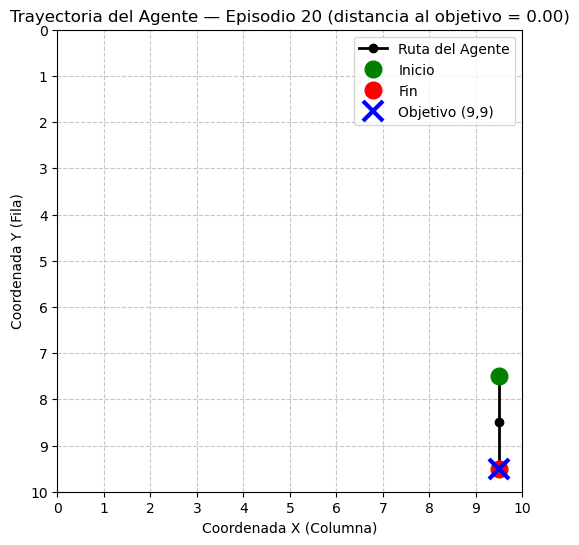

Episodio  21 | Pasos:  14 | Pérdida Posterior: 0.2031 | Pérdida Política: 0.0024 | Pérdida Crítico: 530.7628 | Distancia final al objetivo: 0.00 ✅
Episodio  22 | Pasos:  11 | Pérdida Posterior: 0.2087 | Pérdida Política: 0.0018 | Pérdida Crítico: 475.3396 | Distancia final al objetivo: 0.00 ✅
Episodio  23 | Pasos:   8 | Pérdida Posterior: 0.1887 | Pérdida Política: 0.0017 | Pérdida Crítico: 438.7090 | Distancia final al objetivo: 0.00 ✅
Episodio  24 | Pasos:  17 | Pérdida Posterior: 0.1864 | Pérdida Política: 0.0017 | Pérdida Crítico: 528.8432 | Distancia final al objetivo: 0.00 ✅
Episodio  25 | Pasos:  12 | Pérdida Posterior: 0.2126 | Pérdida Política: 0.0018 | Pérdida Crítico: 457.1098 | Distancia final al objetivo: 0.00 ✅
Episodio  26 | Pasos:  18 | Pérdida Posterior: 0.2038 | Pérdida Política: 0.0018 | Pérdida Crítico: 431.7495 | Distancia final al objetivo: 0.00 ✅
Episodio  27 | Pasos:  14 | Pérdida Posterior: 0.2113 | Pérdida Política: 0.0015 | Pérdida Crítico: 433.5266 | Distanc

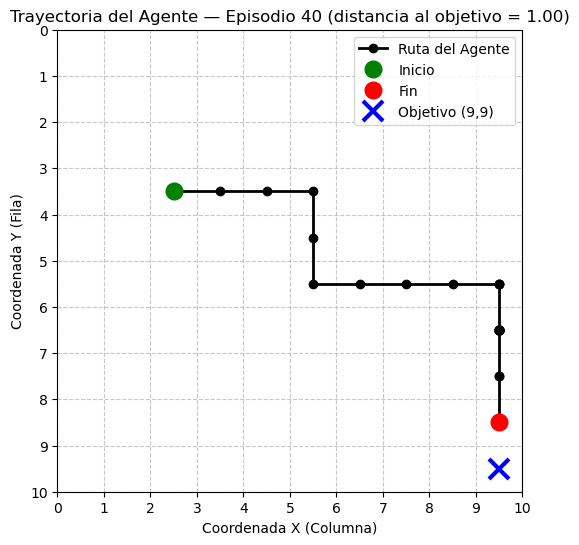

Episodio  41 | Pasos: 150 | Pérdida Posterior: 0.2117 | Pérdida Política: 0.0016 | Pérdida Crítico: 186.6277 | Distancia final al objetivo: 1.00 ❌
Episodio  42 | Pasos:   2 | Pérdida Posterior: 0.2053 | Pérdida Política: 0.0015 | Pérdida Crítico: 196.9267 | Distancia final al objetivo: 0.00 ✅
Episodio  43 | Pasos: 150 | Pérdida Posterior: 0.2085 | Pérdida Política: 0.0015 | Pérdida Crítico: 163.2570 | Distancia final al objetivo: 1.00 ❌
Episodio  44 | Pasos: 150 | Pérdida Posterior: 0.2032 | Pérdida Política: 0.0013 | Pérdida Crítico: 143.4106 | Distancia final al objetivo: 0.00 ✅
Episodio  45 | Pasos:  57 | Pérdida Posterior: 0.2004 | Pérdida Política: 0.0013 | Pérdida Crítico: 154.3187 | Distancia final al objetivo: 0.00 ✅
Episodio  46 | Pasos:   3 | Pérdida Posterior: 0.2252 | Pérdida Política: 0.0013 | Pérdida Crítico: 105.3700 | Distancia final al objetivo: 0.00 ✅
Episodio  47 | Pasos:  47 | Pérdida Posterior: 0.2003 | Pérdida Política: 0.0013 | Pérdida Crítico: 148.8947 | Distanc

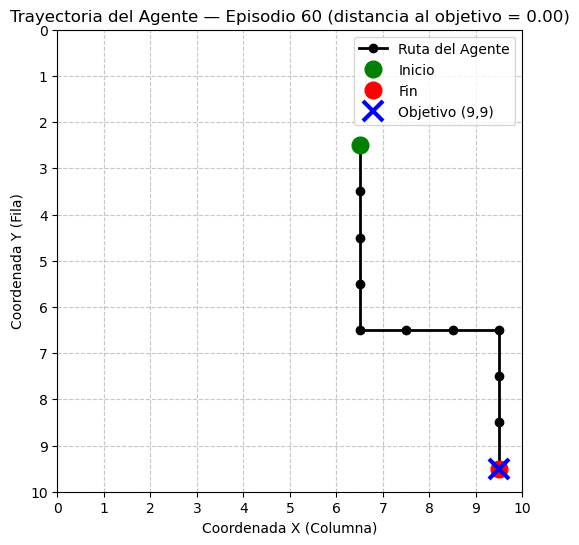

Episodio  61 | Pasos:  59 | Pérdida Posterior: 0.1994 | Pérdida Política: 0.0081 | Pérdida Crítico: 278.8807 | Distancia final al objetivo: 0.00 ✅
Episodio  62 | Pasos:  28 | Pérdida Posterior: 0.1897 | Pérdida Política: 0.0055 | Pérdida Crítico: 196.7048 | Distancia final al objetivo: 0.00 ✅
Episodio  63 | Pasos:  16 | Pérdida Posterior: 0.1840 | Pérdida Política: 0.0106 | Pérdida Crítico: 242.6395 | Distancia final al objetivo: 0.00 ✅
Episodio  64 | Pasos:  14 | Pérdida Posterior: 0.1933 | Pérdida Política: 0.0059 | Pérdida Crítico: 208.0413 | Distancia final al objetivo: 0.00 ✅
Episodio  65 | Pasos:  18 | Pérdida Posterior: 0.1983 | Pérdida Política: 0.0050 | Pérdida Crítico: 187.6325 | Distancia final al objetivo: 0.00 ✅
Episodio  66 | Pasos:   9 | Pérdida Posterior: 0.1841 | Pérdida Política: 0.0054 | Pérdida Crítico: 168.5331 | Distancia final al objetivo: 0.00 ✅
Episodio  67 | Pasos:   4 | Pérdida Posterior: 0.1792 | Pérdida Política: 0.0068 | Pérdida Crítico: 190.6491 | Distanc

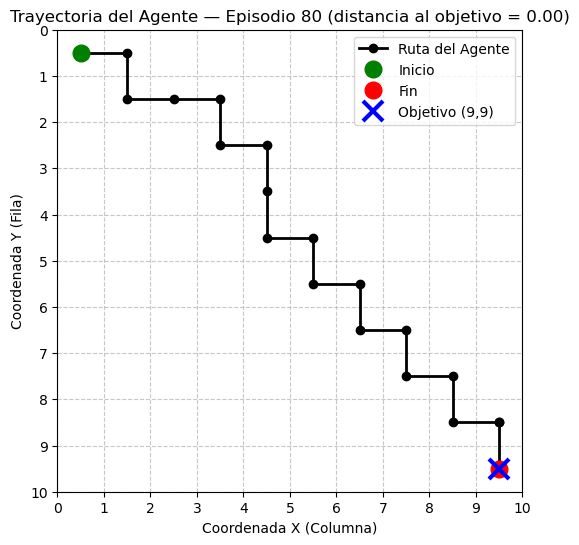

Episodio  81 | Pasos:   9 | Pérdida Posterior: 0.1766 | Pérdida Política: 0.0036 | Pérdida Crítico: 195.8770 | Distancia final al objetivo: 0.00 ✅
Episodio  82 | Pasos:  10 | Pérdida Posterior: 0.1927 | Pérdida Política: 0.0056 | Pérdida Crítico: 151.3904 | Distancia final al objetivo: 0.00 ✅
Episodio  83 | Pasos:   9 | Pérdida Posterior: 0.1942 | Pérdida Política: 0.0053 | Pérdida Crítico: 148.7891 | Distancia final al objetivo: 0.00 ✅
Episodio  84 | Pasos:  11 | Pérdida Posterior: 0.2075 | Pérdida Política: 0.0020 | Pérdida Crítico: 193.4854 | Distancia final al objetivo: 0.00 ✅
Episodio  85 | Pasos:  22 | Pérdida Posterior: 0.2121 | Pérdida Política: 0.0048 | Pérdida Crítico: 220.7379 | Distancia final al objetivo: 0.00 ✅
Episodio  86 | Pasos:  10 | Pérdida Posterior: 0.2067 | Pérdida Política: 0.0091 | Pérdida Crítico: 229.9207 | Distancia final al objetivo: 0.00 ✅
Episodio  87 | Pasos:  17 | Pérdida Posterior: 0.2087 | Pérdida Política: 0.0038 | Pérdida Crítico: 183.7509 | Distanc

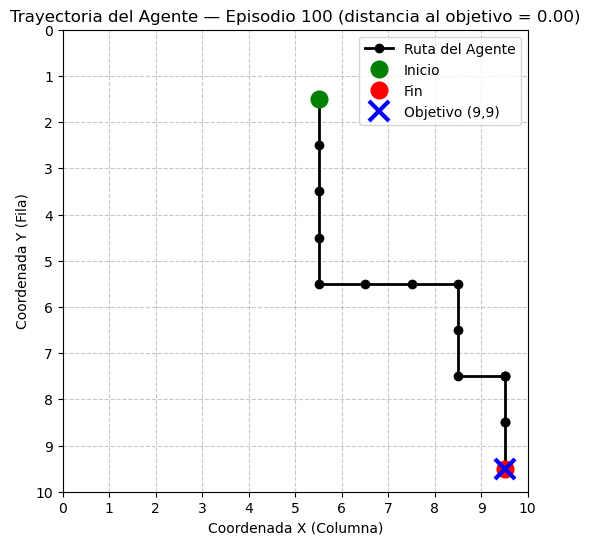


EPISODIO FINAL DE PRUEBA (evaluación pura de la política entrenada)


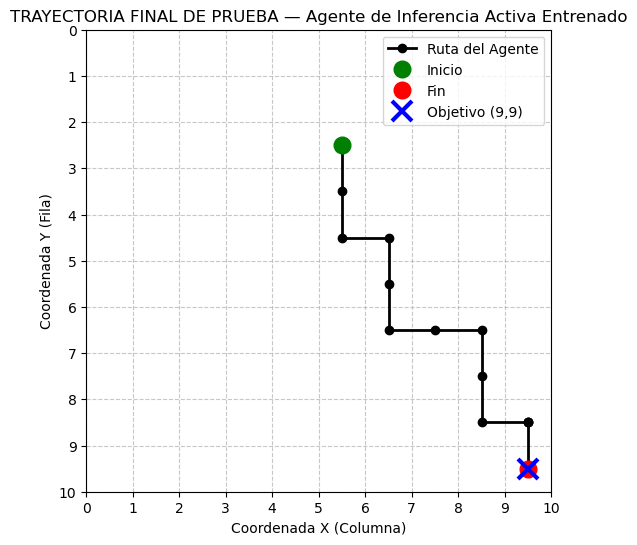

¡Prueba finalizada! Distancia final al objetivo: 0.00 🎉 ¡LLEGÓ AL OBJETIVO!


In [15]:

# =============================================================================
# ENTRENAMIENTO CONJUNTO COMPLETO DEL AGENTE DE INFERENCIA ACTIVA
# =============================================================================
# En esta sección entrenamos las tres redes al mismo tiempo, tal como se
# describe en el resumen de la implementación.

import random
import numpy as np

# ----------------------------------------------------------------------
# Creamos un agente nuevo y un entorno nuevo (desde cero)
# ----------------------------------------------------------------------
agent = ActiveInferenceAgent(state_size=2, action_size=5, lr=1e-3, gamma=0.9, zeta=2.0)
env   = GridWorld(size=10)

# Hiperparámetros
NUM_EPISODES        = 100
MAX_STEPS_PER_EP    = 150
BATCH_SIZE          = 64
TARGET_UPDATE_FREQ  = 200      # pasos globales
total_steps         = 0

print("🚀 Iniciando el entrenamiento conjunto de Inferencia Activa desde cero...\n")

for episode in range(1, NUM_EPISODES + 1):
    obs, true_s = env.reset()
    last_action = np.random.randint(0, env.action_space_size)  # acción fantasma inicial
    
    trajectory = [true_s.copy()]          # para visualizar la trayectoria
    p_losses   = []
    pol_losses = []
    c_losses   = []
    
    for step in range(MAX_STEPS_PER_EP):
        # 1. Inferir el estado actual (estados internos μ)
        inferred_state = agent.infer_state(obs, last_action)
        
        # 2. Elegir acción según la política (estados activos a)
        action = agent.choose_action(inferred_state)
        
        # 3. Ejecutar la acción en el entorno
        next_obs, next_true_s = env.step(action)
        trajectory.append(next_true_s.copy())
        
        # 4. Guardar la experiencia en el replay buffer
        agent.remember(true_s, last_action, action, next_true_s,
                       obs, next_obs, env.goal_location)
        
        # 5. Entrenar si tenemos suficientes datos
        if len(agent.memory) >= BATCH_SIZE:
            p_loss, pol_loss, c_loss = agent.replay(BATCH_SIZE)
            if p_loss is not None:
                p_losses.append(p_loss)
                pol_losses.append(pol_loss)
                c_losses.append(c_loss)
        
        # 6. Actualizar la red objetivo periódicamente (estabilidad)
        total_steps += 1
        if total_steps % TARGET_UPDATE_FREQ == 0:
            agent.update_target_critic()
        
        # 7. Preparar siguiente paso
        obs        = next_obs
        true_s     = next_true_s
        last_action = action
        
        # Detener episodio temprano si llegamos al objetivo
        if np.linalg.norm(true_s - env.goal_location) < 0.8:
            break
    
    # ====================== REPORTE DE PROGRESO ======================
    avg_p   = np.mean(p_losses)   if p_losses   else 0.0
    avg_pol = np.mean(pol_losses) if pol_losses else 0.0
    avg_c   = np.mean(c_losses)   if c_losses   else 0.0
    final_dist = np.linalg.norm(true_s - env.goal_location)
    
    print(f"Episodio {episode:3d} | "
          f"Pasos: {len(trajectory)-1:3d} | "
          f"Pérdida Posterior: {avg_p:6.4f} | "
          f"Pérdida Política: {avg_pol:6.4f} | "
          f"Pérdida Crítico: {avg_c:6.4f} | "
          f"Distancia final al objetivo: {final_dist:.2f} "
          f"{'✅' if final_dist < 1.0 else '❌'}")
    
    # Visualización cada 20 episodios
    if episode % 20 == 0 or episode == NUM_EPISODES:
        plot_trajectory(trajectory,
                        grid_size=env.size,
                        goal_location=env.goal_location,
                        title=f'Trayectoria del Agente — Episodio {episode} '
                              f'(distancia al objetivo = {final_dist:.2f})')

# =============================================================================
# EPISODIO FINAL DE PRUEBA (solo ejecución de la política, sin entrenamiento)
# =============================================================================
print("\n" + "="*70)
print("EPISODIO FINAL DE PRUEBA (evaluación pura de la política entrenada)")
print("="*70)

obs, true_s = env.reset()
trajectory_test = [true_s.copy()]
last_action = 0

for _ in range(200):
    inferred = agent.infer_state(obs, last_action)
    action   = agent.choose_action(inferred)
    next_obs, next_true = env.step(action)
    
    trajectory_test.append(next_true.copy())
    obs = next_obs
    true_s = next_true
    last_action = action
    
    if np.linalg.norm(true_s - env.goal_location) < 0.5:
        break

plot_trajectory(trajectory_test,
                grid_size=env.size,
                goal_location=env.goal_location,
                title='TRAYECTORIA FINAL DE PRUEBA — Agente de Inferencia Activa Entrenado')

dist = np.linalg.norm(true_s - env.goal_location)
print(f"¡Prueba finalizada! Distancia final al objetivo: {dist:.2f} "
      f"{'🎉 ¡LLEGÓ AL OBJETIVO!' if dist < 1.0 else 'Todavía puede mejorar...'}")